In [1]:
%pip install bokeh geopandas

Note: you may need to restart the kernel to use updated packages.


In [2]:

import os
import pathlib

import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from bokeh.io import output_notebook
from bokeh.models import (
    ColorBar,
    ColumnDataSource,
    HoverTool,
    LinearColorMapper,
    WheelZoomTool,
)
from bokeh.models.tiles import WMTSTileSource
from bokeh.palettes import Viridis256
from bokeh.plotting import figure, show
from matplotlib.ticker import AutoLocator, AutoMinorLocator


# helper functions
def filter_extrema(input):
    arr = np.array(input)
    p3 = np.percentile(arr, 3)
    p97 = np.percentile(arr, 97)
    trimmed_arr = arr[(arr >= p3) & (arr <= p97)]
    return trimmed_arr


# Enable Bokeh output inside Jupyter Notebook
output_notebook()


# Force Matplotlib to use Type 42 (TrueType) fonts instead of Type 3
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# Ensure text isn't converted to paths/bitmaps
matplotlib.rcParams['svg.fonttype'] = 'none'

Loading BokehJS ...

In [3]:
PROJECT_ROOT = pathlib.Path('.').cwd().parent # you can also do it manually, for example ~/repos/NdSta2026


print('='*50, '[DATA DIRECTORY]')
DATA_DIR = PROJECT_ROOT / 'data_raw'

print(f"Project Root: {PROJECT_ROOT}")
print(f"Looking for data in: {DATA_DIR}")


print('- '*25)
print('='*50, '[OUTPUT DIRECTORY]')

OUTPUT_DIR = PROJECT_ROOT / 'figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Project Root: {PROJECT_ROOT}")
print(f"All outputs will be in: {OUTPUT_DIR}")

================================================== [DATA DIRECTORY]
Project Root: /home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis
Looking for data in: /home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_raw
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================================== [OUTPUT DIRECTORY]
Project Root: /home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis
All outputs will be in: /home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/figures


# Data count

In [4]:

def count_filtered_data(csv_paths, valid_collections):
    """
    Loads a list of CSV paths, filters by the 'Collection' column, 
    and counts the total number of matching rows.
    """
    total_count = 0
    
    for path in csv_paths:
        try:
            # Load the CSV file
            df = pd.read_csv(path)
            
            # Ensure the 'Collection' column exists in this CSV
            if 'Collection' in df.columns:
                # Filter the dataframe where the 'Collection' is in our predefined list
                filtered_df = df[df['Collection'].isin(valid_collections)]
                
                # Get the number of rows in the filtered dataframe
                current_count = len(filtered_df)
                total_count += current_count
                
                print(f"[{path}] -> Found {current_count} matching rows.")
            else:
                print(f"[{path}] -> Skipped: 'Collection' column not found.")
                
        except Exception as e:
            print(f"[{path}] -> Error processing file: {e}")
            
    return total_count

# ==========================================
# Example Usage:
# ==========================================

# 1. Define your list of CSV file paths
csv_file_paths = [
    DATA_DIR / 'ND_STA_2025/nr_pusch.csv',
    DATA_DIR / 'ND_STA_2025/nr_radio.csv',
    DATA_DIR / 'ND_STA_2025/lte_pdsch_agg.csv',
    DATA_DIR / 'ND_STA_2025/nr_radio_beam.csv',
    DATA_DIR / 'ND_STA_2025/lte_pusch.csv',
    DATA_DIR / 'ND_STA_2025/lte_radio.csv',
    DATA_DIR / 'ND_STA_2025/lte_radio_neig.csv',
    DATA_DIR / 'ND_STA_2025/lte_pdsch.csv',
    DATA_DIR / 'ND_STA_2025/nr_pdsch.csv',
    DATA_DIR / 'ND_STA_2025/nr_pdsch_agg.csv',
    DATA_DIR / 'ND_STA_2026/nr_pusch.csv',
    DATA_DIR / 'ND_STA_2026/nr_radio.csv',
    DATA_DIR / 'ND_STA_2026/lte_pdsch_agg.csv',
    DATA_DIR / '2026_all_qp_csv/messaging.csv',
    DATA_DIR / 'ND_STA_2026/nr_radio_beam.csv',
    DATA_DIR / 'ND_STA_2026/lte_pusch.csv',
    DATA_DIR / 'ND_STA_2026/lte_radio.csv',
    DATA_DIR / '2026_all_qp_csv/browser.csv',
    DATA_DIR / 'ND_STA_2026/lte_radio_neig.csv',
    DATA_DIR / 'ND_STA_2026/lte_pdsch.csv',
    DATA_DIR / 'ND_STA_2026/nr_pdsch.csv',
    DATA_DIR / '2026_all_qp_csv/data_app.csv',
    DATA_DIR / 'ND_STA_2026/nr_pdsch_agg.csv',
] 

# 2. Define the list of collections you want to keep
target_collections = [
    '20250826_preGame_Bowl',
    '20250828_preGame_Bowl',
    '20250913_Game_Bowl',
    '20250920_Game_Bowl',
    '20251108_Game_Bowl',
    '20251122_Game_Bowl',
    '20260226_preGame_Bowl',
]

# 3. Run the function
grand_total = count_filtered_data(csv_file_paths, target_collections)

print("\n-------------------------------------------")
print(f"Grand Total of Matching Rows: {grand_total}")


/tmp/ipykernel_29200/1775656707.py:11: DtypeWarning: Columns (0: Enabled256QAM, 1: Direction) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


[/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_raw/ND_STA_2025/nr_pusch.csv] -> Found 44865 matching rows.


[/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_raw/ND_STA_2025/nr_radio.csv] -> Found 57688 matching rows.


[/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_raw/ND_STA_2025/lte_pdsch_agg.csv] -> Found 70850 matching rows.


/tmp/ipykernel_29200/1775656707.py:11: DtypeWarning: Columns (0: Direction) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


[/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_raw/ND_STA_2025/nr_radio_beam.csv] -> Found 345752 matching rows.


/tmp/ipykernel_29200/1775656707.py:11: DtypeWarning: Columns (0: Subframe Assignment) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


[/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_raw/ND_STA_2025/lte_pusch.csv] -> Found 58338 matching rows.


[/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_raw/ND_STA_2025/lte_radio.csv] -> Found 139960 matching rows.


[/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_raw/ND_STA_2025/lte_radio_neig.csv] -> Found 431756 matching rows.


/tmp/ipykernel_29200/1775656707.py:11: DtypeWarning: Columns (0: Subframe Assignment, 1: Direction) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


[/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_raw/ND_STA_2025/lte_pdsch.csv] -> Found 87491 matching rows.


[/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_raw/ND_STA_2025/nr_pdsch.csv] -> Found 46746 matching rows.


[/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_raw/ND_STA_2025/nr_pdsch_agg.csv] -> Found 44660 matching rows.
[/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_raw/ND_STA_2026/nr_pusch.csv] -> Found 7320 matching rows.
[/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_raw/ND_STA_2026/nr_radio.csv] -> Found 8118 matching rows.
[/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_raw/ND_STA_2026/lte_pdsch_agg.csv] -> Found 4571 matching rows.
[/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_raw/2026_all_qp_csv/messaging.csv] -> Skipped: 'Collection' column not found.


[/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_raw/ND_STA_2026/nr_radio_beam.csv] -> Found 34151 matching rows.
[/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_raw/ND_STA_2026/lte_pusch.csv] -> Found 4135 matching rows.
[/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_raw/ND_STA_2026/lte_radio.csv] -> Found 16485 matching rows.
[/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_raw/2026_all_qp_csv/browser.csv] -> Found 335 matching rows.


[/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_raw/ND_STA_2026/lte_radio_neig.csv] -> Found 43195 matching rows.
[/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_raw/ND_STA_2026/lte_pdsch.csv] -> Found 5875 matching rows.
[/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_raw/ND_STA_2026/nr_pdsch.csv] -> Found 7085 matching rows.
[/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_raw/2026_all_qp_csv/data_app.csv] -> Found 582 matching rows.
[/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_raw/ND_STA_2026/nr_pdsch_agg.csv] -> Found 6808 matching rows.

-------------------------------------------
Grand Total of Matching Rows: 1466766


# Ookla

## Game

In [5]:
# load sigcap wifi for correlation with Ookla data

df_sigcap_wifi_game1 = pd.concat([
    pd.read_csv(DATA_DIR / 'game1_sigcap_csv/20250913_sigcap_sta_wifi_bow.csv', parse_dates=['timestamp']).assign(Location='Bowl'),
    pd.read_csv(DATA_DIR / 'game1_sigcap_csv/20250913_sigcap_sta_wifi_con.csv', parse_dates=['timestamp']).assign(Location='Concourse'),
])
df_sigcap_wifi_game1['timestamp'] = pd.to_datetime(df_sigcap_wifi_game1['timestamp']).dt.tz_localize(None).dt.round('min')
df_sigcap_wifi_game1['uuid'] = df_sigcap_wifi_game1['uuid'].str.slice(0, 8)
df_sigcap_wifi_game1_conn = df_sigcap_wifi_game1[
    (df_sigcap_wifi_game1['connected'] == True)
][['timestamp', 'uuid', 'Location', 'primary_freq_mhz']].groupby(['timestamp', 'uuid']).apply(
    lambda x: x.mode(), include_groups=False
).reset_index().drop(columns=['level_2']).sort_values(by=['timestamp'])

display(df_sigcap_wifi_game1_conn)

# Load ookla data for phones runnning tests on Wi-Fi

df_ookla_wifi_game1 = pd.concat([
    pd.read_csv(DATA_DIR / "game1_ookla_csv/20250913_sta_fg_wifi.csv", parse_dates=["Date"], date_format='%m/%d/%Y, %I:%M %p').rename(columns={"Date": "timestamp"}).assign(uuid="45a367ee"),
    pd.read_csv(DATA_DIR / "game1_ookla_csv/20250913_sta_has_wifi.csv", parse_dates=["Date"], date_format='%m/%d/%Y, %I:%M %p').rename(columns={"Date": "timestamp"}).assign(uuid="deb741c3"),
    pd.read_csv(DATA_DIR / "game1_ookla_csv/20250913_sta_hn_wifi.csv", parse_dates=["Date"], date_format='%m/%d/%Y, %I:%M %p').rename(columns={"Date": "timestamp"}).assign(uuid="a0d207e4"),
]).sort_values(by=["timestamp"])

df_ookla_wifi_game1_merged = pd.merge_asof(
    df_ookla_wifi_game1,
    df_sigcap_wifi_game1_conn,
    on="timestamp",
    by="uuid",
    direction="nearest",
    suffixes=("", "_conn"),
    tolerance=pd.Timedelta(seconds=10),
)

conditions = [
    (df_ookla_wifi_game1_merged['primary_freq_mhz'].between(5000, 5925, inclusive='both')),
    (df_ookla_wifi_game1_merged['primary_freq_mhz'] > 5925),
    (df_ookla_wifi_game1_merged['primary_freq_mhz'] < 5000)
]
choices = ['Wi-Fi 5 GHz', 'Wi-Fi 6 GHz', 'Wi-Fi 2.4 GHz']

df_ookla_wifi_game1_merged['Connection Type'] = np.select(conditions, choices, default='unknown')
df_ookla_wifi_game1_merged = df_ookla_wifi_game1_merged[
    (df_ookla_wifi_game1_merged["Connection Type"] != "unknown")
    & ~(df_ookla_wifi_game1_merged["Location"].isna())
]

display(df_ookla_wifi_game1_merged)

,timestamp,uuid,Location,primary_freq_mhz
0,2025-09-13 19:16:00,45a367ee,Bowl,6455
1,2025-09-13 19:42:00,deb741c3,Bowl,5805
2,2025-09-13 19:43:00,deb741c3,Bowl,5805
3,2025-09-13 19:46:00,deb741c3,Bowl,5785
4,2025-09-13 19:47:00,deb741c3,Bowl,5785
...,...,...,...,...
256,2025-09-13 21:52:00,deb741c3,Concourse,6695
257,2025-09-13 21:53:00,45a367ee,Concourse,5500
258,2025-09-13 21:54:00,45a367ee,Concourse,5240
259,2025-09-13 21:55:00,45a367ee,Concourse,5240


,timestamp,ConnType,Lat,Lon,Download Speed,Download Size,Upload Speed,Upload Size,Latency,Server,InternalIp,ExternalIp,URL,uuid,Location,primary_freq_mhz,Connection Type
920,2025-09-13 19:46:00,Wifi,41.697947,-86.234451,30.104944,46012820.0,23.462160,36962600.0,19,"Climax, MI",10.12.125.125,66.205.174.125,https://www.speedtest.net/my-result/a/11115678599,deb741c3,Bowl,5785.0,Wi-Fi 5 GHz
922,2025-09-13 19:47:00,Wifi,41.697947,-86.234451,39.251952,62187040.0,26.218640,41509630.0,23,"Climax, MI",10.12.125.125,66.205.174.125,https://www.speedtest.net/my-result/a/11115679363,deb741c3,Bowl,5785.0,Wi-Fi 5 GHz
925,2025-09-13 19:48:00,Wifi,41.697980,-86.234415,31.729248,50721498.0,25.604312,37796930.0,20,"Climax, MI",10.12.125.125,66.205.174.125,https://www.speedtest.net/my-result/a/11115680448,deb741c3,Bowl,5785.0,Wi-Fi 5 GHz
926,2025-09-13 19:49:00,Wifi,41.697961,-86.234478,18.555400,27540490.0,16.181160,24413400.0,16,"Climax, MI",10.12.125.125,66.205.174.125,https://www.speedtest.net/my-result/a/11115681348,deb741c3,Bowl,5785.0,Wi-Fi 5 GHz
927,2025-09-13 19:49:00,Wifi,41.697720,-86.233823,59.421440,82591820.0,59.917864,68527400.0,18,"South Bend, IN",10.12.21.156,66.205.174.156,https://www.speedtest.net/my-result/a/11115680666,45a367ee,Bowl,5240.0,Wi-Fi 5 GHz
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1078,2025-09-13 21:49:00,Wifi,41.698305,-86.234672,50.393672,61532180.0,10.491568,11921740.0,17,"Climax, MI",10.12.21.156,66.205.174.156,https://www.speedtest.net/my-result/a/11115781949,45a367ee,Concourse,5785.0,Wi-Fi 5 GHz
1079,2025-09-13 21:49:00,Wifi,41.698305,-86.234672,72.163248,96231540.0,16.762168,27510970.0,18,"Climax, MI",10.12.21.156,66.205.174.156,https://www.speedtest.net/my-result/a/11115782559,45a367ee,Concourse,5785.0,Wi-Fi 5 GHz
1080,2025-09-13 21:50:00,Wifi,41.698305,-86.234672,22.428608,12468164.0,14.441296,22955720.0,17,"Climax, MI",10.12.21.156,66.205.174.156,https://www.speedtest.net/my-result/a/11115783209,45a367ee,Concourse,5785.0,Wi-Fi 5 GHz
1081,2025-09-13 21:54:00,Wifi,41.699361,-86.234841,43.039440,52586080.0,26.504744,44446910.0,18,"Climax, MI",10.12.21.156,66.205.174.156,https://www.speedtest.net/my-result/a/11115786571,45a367ee,Concourse,5240.0,Wi-Fi 5 GHz


In [6]:
# load sigcap wifi for correlation with Ookla data

df_sigcap_wifi_game2 = pd.concat([
    pd.read_csv(DATA_DIR / 'game2_sigcap_csv/20250920_sigcap_sta_wifi_bow.csv', parse_dates=['timestamp']).assign(Location='Bowl'),
    pd.read_csv(DATA_DIR / 'game2_sigcap_csv/20250920_sigcap_sta_wifi_con.csv', parse_dates=['timestamp']).assign(Location='Concourse'),
])
df_sigcap_wifi_game2['timestamp'] = pd.to_datetime(df_sigcap_wifi_game2['timestamp']).dt.tz_localize(None).dt.round('min')
df_sigcap_wifi_game2['uuid'] = df_sigcap_wifi_game2['uuid'].str.slice(0, 8)
df_sigcap_wifi_game2_conn = df_sigcap_wifi_game2[
    (df_sigcap_wifi_game2['connected'] == True)
][['timestamp', 'uuid', 'Location', 'primary_freq_mhz']].groupby(['timestamp', 'uuid']).apply(
    lambda x: x.mode(), include_groups=False
).reset_index().drop(columns=['level_2']).sort_values(by=['timestamp'])

display(df_sigcap_wifi_game2_conn)

# Load ookla data for phones runnning tests on Wi-Fi

df_ookla_wifi_game2 = pd.concat([
    pd.read_csv(DATA_DIR / "game2_ookla_csv/20250920_sta_at_wifi.csv", parse_dates=["Date"], date_format='%m/%d/%Y, %I:%M %p').rename(columns={"Date": "timestamp"}).assign(uuid="a0d207e4"),
    pd.read_csv(DATA_DIR / "game2_ookla_csv/20250920_sta_jrp_wifi.csv", parse_dates=["Date"], date_format='%m/%d/%Y, %I:%M %p').rename(columns={"Date": "timestamp"}).assign(uuid="45a367ee"),
    pd.read_csv(DATA_DIR / "game2_ookla_csv/20250920_sta_hn_wifi.csv", parse_dates=["Date"], date_format='%m/%d/%Y, %I:%M %p').rename(columns={"Date": "timestamp"}).assign(uuid="058d24ab"),
]).sort_values(by=["timestamp"])

df_ookla_wifi_game2_merged = pd.merge_asof(
    df_ookla_wifi_game2,
    df_sigcap_wifi_game2_conn,
    on="timestamp",
    by="uuid",
    direction="nearest",
    suffixes=("", "_conn"),
    tolerance=pd.Timedelta(seconds=10),
)

conditions = [
    (df_ookla_wifi_game2_merged['primary_freq_mhz'].between(5000, 5925, inclusive='both')),
    (df_ookla_wifi_game2_merged['primary_freq_mhz'] > 5925),
    (df_ookla_wifi_game2_merged['primary_freq_mhz'] < 5000)
]
choices = ['Wi-Fi 5 GHz', 'Wi-Fi 6 GHz', 'Wi-Fi 2.4 GHz']

df_ookla_wifi_game2_merged['Connection Type'] = np.select(conditions, choices, default='unknown')
df_ookla_wifi_game2_merged = df_ookla_wifi_game2_merged[
    (df_ookla_wifi_game2_merged["Connection Type"] != "unknown")
    & ~(df_ookla_wifi_game2_merged["Location"].isna())
]

display(df_ookla_wifi_game2_merged)

,timestamp,uuid,Location,primary_freq_mhz
0,2025-09-20 15:52:00,a0d207e4,Bowl,5240
1,2025-09-20 15:53:00,a0d207e4,Bowl,5240
2,2025-09-20 15:54:00,a0d207e4,Bowl,5240
3,2025-09-20 15:55:00,058d24ab,Bowl,6055
4,2025-09-20 15:55:00,a0d207e4,Bowl,5240
...,...,...,...,...
159,2025-09-20 17:06:00,45a367ee,Concourse,6695
160,2025-09-20 17:07:00,45a367ee,Concourse,6695
161,2025-09-20 17:08:00,45a367ee,Concourse,6695
162,2025-09-20 17:09:00,a0d207e4,Bowl,5975


,timestamp,ConnType,Lat,Lon,Download Speed,Download Size,Upload Speed,Upload Size,Latency,Server,InternalIp,ExternalIp,URL,uuid,Location,primary_freq_mhz,Connection Type
1088,2025-09-20 15:53:00,Wifi,41.698609,-86.233358,57.640440,89237513.0,22.027448,3218130.0,26,"Warsaw, IN",10.12.172.230,66.205.174.230,https://www.speedtest.net/my-result/a/11128943370,a0d207e4,Bowl,5240.0,Wi-Fi 5 GHz
1089,2025-09-20 15:53:00,Wifi,41.698609,-86.233358,42.855784,61427297.0,37.165240,48223438.0,21,"Warsaw, IN",10.12.172.230,66.205.174.230,https://www.speedtest.net/my-result/a/11128944204,a0d207e4,Bowl,5240.0,Wi-Fi 5 GHz
1090,2025-09-20 15:54:00,Wifi,41.698574,-86.233377,46.370192,59875850.0,24.691400,37118780.0,23,"Warsaw, IN",10.12.172.230,66.205.174.230,https://www.speedtest.net/my-result/a/11128945010,a0d207e4,Bowl,5240.0,Wi-Fi 5 GHz
1091,2025-09-20 15:55:00,Wifi,41.698632,-86.233429,34.207200,47960948.0,32.171408,53758800.0,17,"Climax, MI",10.12.211.85,66.205.174.85,https://www.speedtest.net/my-result/a/11128946269,058d24ab,Bowl,6055.0,Wi-Fi 6 GHz
1092,2025-09-20 15:55:00,Wifi,41.698578,-86.233372,36.565608,48130840.0,14.845224,25254580.0,20,"Warsaw, IN",10.12.172.230,66.205.174.230,https://www.speedtest.net/my-result/a/11128945923,a0d207e4,Bowl,5240.0,Wi-Fi 5 GHz
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1177,2025-09-20 17:00:00,Wifi,41.698837,-86.234470,7.468736,8971430.0,1.333520,1607010.0,18,"South Bend, IN",10.12.172.230,66.205.174.230,https://www.speedtest.net/my-result/a/-1,a0d207e4,Bowl,6215.0,Wi-Fi 6 GHz
1178,2025-09-20 17:02:00,Wifi,41.697394,-86.234645,171.640880,287608210.0,216.293536,121863270.0,16,"Climax, MI",10.12.21.156,66.205.174.156,https://www.speedtest.net/my-result/a/11129018493,45a367ee,Concourse,6695.0,Wi-Fi 6 GHz
1179,2025-09-20 17:02:00,Wifi,41.697394,-86.234645,157.152080,215903780.0,224.383696,126560515.0,16,"Climax, MI",10.12.21.156,66.205.174.156,https://www.speedtest.net/my-result/a/11129019077,45a367ee,Concourse,6695.0,Wi-Fi 6 GHz
1181,2025-09-20 17:05:00,Wifi,41.697417,-86.233425,165.807344,196793650.0,43.116032,62651470.0,16,"Climax, MI",10.12.21.156,66.205.174.156,https://www.speedtest.net/my-result/a/11129022262,45a367ee,Concourse,6055.0,Wi-Fi 6 GHz


In [7]:
# load sigcap cell for correlation with Ookla data

df_sigcap_cell_game1 = pd.concat([
    pd.read_csv(DATA_DIR / 'game1_sigcap_csv/20250913_sigcap_sta_cell_bow.csv', parse_dates=['timestamp']).assign(Location='Bowl'),
    pd.read_csv(DATA_DIR / 'game1_sigcap_csv/20250913_sigcap_sta_cell_con.csv', parse_dates=['timestamp']).assign(Location='Concourse'),
])
df_sigcap_cell_game1['timestamp'] = pd.to_datetime(df_sigcap_cell_game1['timestamp']).dt.tz_localize(None).dt.round('min')
df_sigcap_cell_game1['uuid'] = df_sigcap_cell_game1['uuid'].str.slice(0, 8)
df_sigcap_cell_game1_conn = df_sigcap_cell_game1[[
    'timestamp', 'uuid', 'Location', "operator", "network_type*"
]].groupby(['timestamp', 'uuid']).apply(
    lambda x: x.mode(), include_groups=False
).reset_index().drop(columns=['level_2']).sort_values(by=['timestamp'])

display(df_sigcap_cell_game1_conn)

# Load ookla data for phones runnning tests on Wi-Fi

df_ookla_cell_game1 = pd.concat([
    pd.read_csv(DATA_DIR / "game1_ookla_csv/20250913_sta_fg_att.csv", parse_dates=["Date"], date_format='%m/%d/%Y, %I:%M %p').rename(columns={"Date": "timestamp"}).assign(uuid="7c36e7df"),
    pd.read_csv(DATA_DIR / "game1_ookla_csv/20250913_sta_has_tmo.csv", parse_dates=["Date"], date_format='%m/%d/%Y, %I:%M %p').rename(columns={"Date": "timestamp"}).assign(uuid="64957d65"),
    pd.read_csv(DATA_DIR / "game1_ookla_csv/20250913_sta_hn_vzw.csv", parse_dates=["Date"], date_format='%m/%d/%Y, %I:%M %p').rename(columns={"Date": "timestamp"}).assign(uuid="a0654bd3"),
]).sort_values(by=["timestamp"])

df_ookla_cell_game1_merged = pd.merge_asof(
    df_ookla_cell_game1,
    df_sigcap_cell_game1_conn,
    on="timestamp",
    by="uuid",
    direction="nearest",
    suffixes=("", "_conn"),
    tolerance=pd.Timedelta(seconds=10),
)

# df_ookla_cell_game1_merged['Connection Type'] = df_ookla_cell_game1_merged['operator'] + ' ' + df_ookla_cell_game1_merged['network_type*']
df_ookla_cell_game1_merged['Connection Type'] = df_ookla_cell_game1_merged['operator']
df_ookla_cell_game1_merged = df_ookla_cell_game1_merged[
    (df_ookla_cell_game1_merged["Connection Type"] != "unknown")
    & ~(df_ookla_cell_game1_merged["Location"].isna())
]
    
display(df_ookla_cell_game1_merged)

,timestamp,uuid,Location,operator,network_type*
0,2025-09-13 19:42:00,64957d65,Bowl,T-Mobile,NR-NSA
1,2025-09-13 19:43:00,64957d65,Bowl,T-Mobile,NR-NSA
2,2025-09-13 19:46:00,64957d65,Bowl,T-Mobile,NR
3,2025-09-13 19:47:00,64957d65,Bowl,T-Mobile,NR
4,2025-09-13 19:48:00,64957d65,Bowl,T-Mobile,NR
...,...,...,...,...,...
283,2025-09-13 21:52:00,7c36e7df,Concourse,AT&T,LTE
284,2025-09-13 21:53:00,7c36e7df,Concourse,AT&T,NR-NSA
285,2025-09-13 21:54:00,7c36e7df,Concourse,AT&T,NR-NSA
286,2025-09-13 21:55:00,7c36e7df,Concourse,AT&T,NR-NSA


,timestamp,ConnType,Lat,Lon,Download Speed,Download Size,Upload Speed,Upload Size,Latency,Server,InternalIp,ExternalIp,URL,uuid,Location,operator,network_type*,Connection Type
763,2025-09-13 19:46:00,Nr,41.697940,-86.234478,124.478808,193578840.0,0.957360,1723680.0,27,"Elgin, IL",2607:fb90:bb89:862e:249d:8488:7009:35cc,2607:fb90:bb89:862e:249d:8488:7009:35cc,https://www.speedtest.net/my-result/a/11115678604,64957d65,Bowl,T-Mobile,NR,T-Mobile
767,2025-09-13 19:47:00,Nr,41.697934,-86.234476,86.567288,132289768.0,1.759152,2975400.0,24,"Elgin, IL",2607:fb90:bb89:862e:249d:8488:7009:35cc,2607:fb90:bb89:862e:249d:8488:7009:35cc,https://www.speedtest.net/my-result/a/11115679229,64957d65,Bowl,T-Mobile,NR,T-Mobile
769,2025-09-13 19:48:00,Nr,41.697942,-86.234576,149.362304,215186336.0,9.095384,13149216.0,28,"Elgin, IL",2607:fb90:bb89:862e:249d:8488:7009:35cc,2607:fb90:bb89:862e:249d:8488:7009:35cc,https://www.speedtest.net/my-result/a/11115680490,64957d65,Bowl,T-Mobile,NR,T-Mobile
770,2025-09-13 19:49:00,Nr,41.697952,-86.234612,104.533296,122810135.0,8.140928,12363984.0,31,"Elgin, IL",2607:fb90:bb89:862e:249d:8488:7009:35cc,2607:fb90:bb89:862e:249d:8488:7009:35cc,https://www.speedtest.net/my-result/a/11115681105,64957d65,Bowl,T-Mobile,NR,T-Mobile
773,2025-09-13 19:52:00,Nr,41.697936,-86.234588,97.866048,119005060.0,19.500232,32971536.0,29,"Milwaukee, WI",2607:fb90:bb89:862e:249d:8488:7009:35cc,2607:fb90:bb89:862e:249d:8488:7009:35cc,https://www.speedtest.net/my-result/a/11115683445,64957d65,Bowl,T-Mobile,NR,T-Mobile
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
927,2025-09-13 21:48:00,Nr,41.699025,-86.233588,467.093328,790473401.0,35.946456,61997760.0,24,"Elgin, IL",2607:fb90:bb89:862e:249d:8488:7009:35cc,2607:fb90:bb89:862e:249d:8488:7009:35cc,https://www.speedtest.net/my-result/a/11115781417,64957d65,Concourse,T-Mobile,NR,T-Mobile
930,2025-09-13 21:50:00,Nr,41.698338,-86.234670,66.763840,83219910.0,4.761344,7467642.0,31,"Akron, OH",2600:382:ac12:a31e:2415:45d6:6766:6dd2,2600:382:ac12:a31e:2415:45d6:6766:6dd2,https://www.speedtest.net/my-result/a/11115783559,7c36e7df,Concourse,AT&T,NR-NSA,AT&T
931,2025-09-13 21:52:00,Nr,41.698673,-86.234806,37.645256,47007370.0,0.818896,1324050.0,32,"Akron, OH",2600:382:ac12:a31e:2415:45d6:6766:6dd2,2600:382:ac12:a31e:2415:45d6:6766:6dd2,https://www.speedtest.net/my-result/a/11115785661,7c36e7df,Concourse,AT&T,LTE,AT&T
932,2025-09-13 21:54:00,Nr,41.699352,-86.234984,23.416816,30163630.0,2.106680,3198090.0,35,"Akron, OH",2600:382:ac12:a31e:2415:45d6:6766:6dd2,2600:382:ac12:a31e:2415:45d6:6766:6dd2,https://www.speedtest.net/my-result/a/11115787449,7c36e7df,Concourse,AT&T,NR-NSA,AT&T


In [8]:
# load sigcap cell for correlation with Ookla data

df_sigcap_cell_game2 = pd.concat([
    pd.read_csv(DATA_DIR / 'game2_sigcap_csv/20250920_sigcap_sta_cell_bow.csv', parse_dates=['timestamp']).assign(Location='Bowl'),
    pd.read_csv(DATA_DIR / 'game2_sigcap_csv/20250920_sigcap_sta_cell_con.csv', parse_dates=['timestamp']).assign(Location='Concourse'),
])
df_sigcap_cell_game2['timestamp'] = pd.to_datetime(df_sigcap_cell_game2['timestamp']).dt.tz_localize(None).dt.round('min')
df_sigcap_cell_game2['uuid'] = df_sigcap_cell_game2['uuid'].str.slice(0, 8)
df_sigcap_cell_game2_conn = df_sigcap_cell_game2[[
    'timestamp', 'uuid', 'Location', "operator", "network_type*"
]].groupby(['timestamp', 'uuid']).apply(
    lambda x: x.mode(), include_groups=False
).reset_index().drop(columns=['level_2']).sort_values(by=['timestamp'])

display(df_sigcap_cell_game2_conn)

# Load ookla data for phones runnning tests on Wi-Fi

df_ookla_cell_game2 = pd.concat([
    pd.read_csv(DATA_DIR / "game2_ookla_csv/20250920_sta_at_tmo.csv", parse_dates=["Date"], date_format='%m/%d/%Y, %I:%M %p').rename(columns={"Date": "timestamp"}).assign(uuid="7c36e7df"),
    pd.read_csv(DATA_DIR / "game2_ookla_csv/20250920_sta_jrp_att.csv", parse_dates=["Date"], date_format='%m/%d/%Y, %I:%M %p').rename(columns={"Date": "timestamp"}).assign(uuid="64957d65"),
    pd.read_csv(DATA_DIR / "game2_ookla_csv/20250920_sta_hn_vzw.csv", parse_dates=["Date"], date_format='%m/%d/%Y, %I:%M %p').rename(columns={"Date": "timestamp"}).assign(uuid="a0654bd3"),
]).sort_values(by=["timestamp"])

df_ookla_cell_game2_merged = pd.merge_asof(
    df_ookla_cell_game2,
    df_sigcap_cell_game2_conn,
    on="timestamp",
    by="uuid",
    direction="nearest",
    suffixes=("", "_conn"),
    tolerance=pd.Timedelta(seconds=10),
)

# df_ookla_cell_game2_merged['Connection Type'] = df_ookla_cell_game2_merged['operator'] + ' ' + df_ookla_cell_game2_merged['network_type*']
df_ookla_cell_game2_merged['Connection Type'] = df_ookla_cell_game2_merged['operator']
df_ookla_cell_game2_merged = df_ookla_cell_game2_merged[
    (df_ookla_cell_game2_merged["Connection Type"] != "unknown")
    & ~(df_ookla_cell_game2_merged["Location"].isna())
]
    
display(df_ookla_cell_game2_merged)

/tmp/ipykernel_29200/2618103298.py:4: DtypeWarning: Columns (0: cellBandwidths) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv(DATA_DIR / 'game2_sigcap_csv/20250920_sigcap_sta_cell_bow.csv', parse_dates=['timestamp']).assign(Location='Bowl'),


,timestamp,uuid,Location,operator,network_type*
0,2025-09-20 15:53:00,a0654bd3,Bowl,Verizon,NR-NSA
1,2025-09-20 15:54:00,7c36e7df,Bowl,T-Mobile,NR
2,2025-09-20 15:54:00,a0654bd3,Bowl,Verizon,NR-NSA
3,2025-09-20 15:55:00,7c36e7df,Bowl,T-Mobile,NR
4,2025-09-20 15:55:00,a0654bd3,Bowl,Verizon,NR-NSA
...,...,...,...,...,...
186,2025-09-20 17:07:00,64957d65,Concourse,AT&T,NR-NSA
187,2025-09-20 17:08:00,64957d65,Concourse,AT&T,NR-NSA
188,2025-09-20 17:08:00,7c36e7df,Bowl,T-Mobile,NR-NSA
189,2025-09-20 17:10:00,7c36e7df,Bowl,T-Mobile,NR-NSA


,timestamp,ConnType,Lat,Lon,Download Speed,Download Size,Upload Speed,Upload Size,Latency,Server,InternalIp,ExternalIp,URL,uuid,Location,operator,network_type*,Connection Type
939,2025-09-20 15:53:00,Nr,41.698583,-86.233393,1.528112,2637420.0,0.006328,17628.0,60,"South Bend, IN",2600:1008:b0ac:e05d:91d7:a237:6024:aaf6,2600:1008:b0ac:e05d:91d7:a237:6024:aaf6,https://www.speedtest.net/my-result/a/-1,a0654bd3,Bowl,Verizon,NR-NSA,Verizon
940,2025-09-20 15:54:00,Nr,41.698599,-86.233427,141.792016,213596052.0,8.563544,13103712.0,39,"LaGrange, IN",192.0.0.2,172.56.249.232,https://www.speedtest.net/my-result/a/11128944724,7c36e7df,Bowl,T-Mobile,NR,T-Mobile
941,2025-09-20 15:55:00,Nr,41.698568,-86.233413,135.662272,79541124.0,10.807280,15945064.0,36,"LaGrange, IN",192.0.0.2,172.56.249.232,https://www.speedtest.net/my-result/a/11128945659,7c36e7df,Bowl,T-Mobile,NR,T-Mobile
942,2025-09-20 15:56:00,Nr,41.698580,-86.233078,134.205888,190509429.0,3.119176,4861992.0,43,"LaGrange, IN",192.0.0.2,172.56.249.232,https://www.speedtest.net/my-result/a/11128947599,7c36e7df,Bowl,T-Mobile,NR,T-Mobile
943,2025-09-20 15:57:00,Nr,41.698584,-86.233081,57.839176,48103333.0,3.144336,4961640.0,39,"LaGrange, IN",192.0.0.2,172.56.249.232,https://www.speedtest.net/my-result/a/11128948352,7c36e7df,Bowl,T-Mobile,NR,T-Mobile
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039,2025-09-20 17:06:00,Nr,41.698667,-86.234666,334.528736,415448853.0,12.015304,9281104.0,33,"LaGrange, IN",192.0.0.2,172.56.248.148,https://www.speedtest.net/my-result/a/11129022802,7c36e7df,Bowl,T-Mobile,NR,T-Mobile
1040,2025-09-20 17:06:00,Nr,41.697521,-86.233416,59.409064,83703246.0,7.388656,12232506.0,39,"Vicksburg, MI",10.30.228.9,107.122.244.113,https://www.speedtest.net/my-result/a/11129023365,64957d65,Concourse,AT&T,NR-NSA,AT&T
1041,2025-09-20 17:06:00,Nr,41.697427,-86.233467,88.573856,127827074.0,15.478328,22289150.0,56,"Vicksburg, MI",10.30.228.9,107.122.244.113,https://www.speedtest.net/my-result/a/11129022586,64957d65,Concourse,AT&T,NR-NSA,AT&T
1042,2025-09-20 17:08:00,Nr,41.698449,-86.234463,39.862360,63049183.0,6.367600,9568976.0,35,"LaGrange, IN",192.0.0.2,172.56.248.148,https://www.speedtest.net/my-result/a/11129024679,7c36e7df,Bowl,T-Mobile,NR-NSA,T-Mobile


In [9]:
df_ookla = pd.concat([
    df_ookla_wifi_game1_merged.assign(**{'Game #': 'Game 1'}),
    df_ookla_cell_game1_merged.assign(**{'Game #': 'Game 1'}),
    df_ookla_wifi_game2_merged.assign(**{'Game #': 'Game 2'}),
    df_ookla_cell_game2_merged.assign(**{'Game #': 'Game 2'})
]).sort_values(by=["timestamp"]).reset_index(drop=True)

display(df_ookla)

,timestamp,ConnType,Lat,Lon,Download Speed,Download Size,Upload Speed,Upload Size,Latency,Server,InternalIp,ExternalIp,URL,uuid,Location,primary_freq_mhz,Connection Type,Game #,operator,network_type*
0,2025-09-13 19:46:00,Wifi,41.697947,-86.234451,30.104944,46012820.0,23.462160,36962600.0,19,"Climax, MI",10.12.125.125,66.205.174.125,https://www.speedtest.net/my-result/a/11115678599,deb741c3,Bowl,5785.0,Wi-Fi 5 GHz,Game 1,NaN,NaN
1,2025-09-13 19:46:00,Nr,41.697940,-86.234478,124.478808,193578840.0,0.957360,1723680.0,27,"Elgin, IL",2607:fb90:bb89:862e:249d:8488:7009:35cc,2607:fb90:bb89:862e:249d:8488:7009:35cc,https://www.speedtest.net/my-result/a/11115678604,64957d65,Bowl,NaN,T-Mobile,Game 1,T-Mobile,NR
2,2025-09-13 19:47:00,Nr,41.697934,-86.234476,86.567288,132289768.0,1.759152,2975400.0,24,"Elgin, IL",2607:fb90:bb89:862e:249d:8488:7009:35cc,2607:fb90:bb89:862e:249d:8488:7009:35cc,https://www.speedtest.net/my-result/a/11115679229,64957d65,Bowl,NaN,T-Mobile,Game 1,T-Mobile,NR
3,2025-09-13 19:47:00,Wifi,41.697947,-86.234451,39.251952,62187040.0,26.218640,41509630.0,23,"Climax, MI",10.12.125.125,66.205.174.125,https://www.speedtest.net/my-result/a/11115679363,deb741c3,Bowl,5785.0,Wi-Fi 5 GHz,Game 1,NaN,NaN
4,2025-09-13 19:48:00,Wifi,41.697980,-86.234415,31.729248,50721498.0,25.604312,37796930.0,20,"Climax, MI",10.12.125.125,66.205.174.125,https://www.speedtest.net/my-result/a/11115680448,deb741c3,Bowl,5785.0,Wi-Fi 5 GHz,Game 1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
497,2025-09-20 17:06:00,Nr,41.698667,-86.234666,334.528736,415448853.0,12.015304,9281104.0,33,"LaGrange, IN",192.0.0.2,172.56.248.148,https://www.speedtest.net/my-result/a/11129022802,7c36e7df,Bowl,NaN,T-Mobile,Game 2,T-Mobile,NR
498,2025-09-20 17:06:00,Nr,41.697521,-86.233416,59.409064,83703246.0,7.388656,12232506.0,39,"Vicksburg, MI",10.30.228.9,107.122.244.113,https://www.speedtest.net/my-result/a/11129023365,64957d65,Concourse,NaN,AT&T,Game 2,AT&T,NR-NSA
499,2025-09-20 17:06:00,Nr,41.697427,-86.233467,88.573856,127827074.0,15.478328,22289150.0,56,"Vicksburg, MI",10.30.228.9,107.122.244.113,https://www.speedtest.net/my-result/a/11129022586,64957d65,Concourse,NaN,AT&T,Game 2,AT&T,NR-NSA
500,2025-09-20 17:08:00,Nr,41.698449,-86.234463,39.862360,63049183.0,6.367600,9568976.0,35,"LaGrange, IN",192.0.0.2,172.56.248.148,https://www.speedtest.net/my-result/a/11129024679,7c36e7df,Bowl,NaN,T-Mobile,Game 2,T-Mobile,NR-NSA


In [10]:
df_ookla_scaled = df_ookla.copy()
# Old scale from lab
# scale_coef_5ghz_dl = 2.44
# scale_coef_5ghz_ul = 2.23
# scale_coef_6ghz_dl = 2.44
# scale_coef_6ghz_ul = 2.23
scale_coef_5ghz_dl = 1.89
scale_coef_5ghz_ul = 2.10
scale_coef_6ghz_dl = 1.89
scale_coef_6ghz_ul = 2.10

df_ookla_scaled['Download Speed'] = df_ookla_scaled.apply(
    lambda x: x['Download Speed'] * scale_coef_5ghz_dl if x['Connection Type'] == 'Wi-Fi 5 GHz' else x['Download Speed'] * scale_coef_6ghz_dl if x['Connection Type'] == 'Wi-Fi 6 GHz' else x['Download Speed'],
    axis=1
)
df_ookla_scaled['Upload Speed'] = df_ookla_scaled.apply(
    lambda x: x['Upload Speed'] * scale_coef_5ghz_ul if x['Connection Type'] == 'Wi-Fi 5 GHz' else x['Upload Speed'] * scale_coef_6ghz_ul if x['Connection Type'] == 'Wi-Fi 6 GHz' else x['Upload Speed'],
    axis=1
)

display(df_ookla_scaled)

,timestamp,ConnType,Lat,Lon,Download Speed,Download Size,Upload Speed,Upload Size,Latency,Server,InternalIp,ExternalIp,URL,uuid,Location,primary_freq_mhz,Connection Type,Game #,operator,network_type*
0,2025-09-13 19:46:00,Wifi,41.697947,-86.234451,56.898344,46012820.0,49.270536,36962600.0,19,"Climax, MI",10.12.125.125,66.205.174.125,https://www.speedtest.net/my-result/a/11115678599,deb741c3,Bowl,5785.0,Wi-Fi 5 GHz,Game 1,NaN,NaN
1,2025-09-13 19:46:00,Nr,41.697940,-86.234478,124.478808,193578840.0,0.957360,1723680.0,27,"Elgin, IL",2607:fb90:bb89:862e:249d:8488:7009:35cc,2607:fb90:bb89:862e:249d:8488:7009:35cc,https://www.speedtest.net/my-result/a/11115678604,64957d65,Bowl,NaN,T-Mobile,Game 1,T-Mobile,NR
2,2025-09-13 19:47:00,Nr,41.697934,-86.234476,86.567288,132289768.0,1.759152,2975400.0,24,"Elgin, IL",2607:fb90:bb89:862e:249d:8488:7009:35cc,2607:fb90:bb89:862e:249d:8488:7009:35cc,https://www.speedtest.net/my-result/a/11115679229,64957d65,Bowl,NaN,T-Mobile,Game 1,T-Mobile,NR
3,2025-09-13 19:47:00,Wifi,41.697947,-86.234451,74.186189,62187040.0,55.059144,41509630.0,23,"Climax, MI",10.12.125.125,66.205.174.125,https://www.speedtest.net/my-result/a/11115679363,deb741c3,Bowl,5785.0,Wi-Fi 5 GHz,Game 1,NaN,NaN
4,2025-09-13 19:48:00,Wifi,41.697980,-86.234415,59.968279,50721498.0,53.769055,37796930.0,20,"Climax, MI",10.12.125.125,66.205.174.125,https://www.speedtest.net/my-result/a/11115680448,deb741c3,Bowl,5785.0,Wi-Fi 5 GHz,Game 1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
497,2025-09-20 17:06:00,Nr,41.698667,-86.234666,334.528736,415448853.0,12.015304,9281104.0,33,"LaGrange, IN",192.0.0.2,172.56.248.148,https://www.speedtest.net/my-result/a/11129022802,7c36e7df,Bowl,NaN,T-Mobile,Game 2,T-Mobile,NR
498,2025-09-20 17:06:00,Nr,41.697521,-86.233416,59.409064,83703246.0,7.388656,12232506.0,39,"Vicksburg, MI",10.30.228.9,107.122.244.113,https://www.speedtest.net/my-result/a/11129023365,64957d65,Concourse,NaN,AT&T,Game 2,AT&T,NR-NSA
499,2025-09-20 17:06:00,Nr,41.697427,-86.233467,88.573856,127827074.0,15.478328,22289150.0,56,"Vicksburg, MI",10.30.228.9,107.122.244.113,https://www.speedtest.net/my-result/a/11129022586,64957d65,Concourse,NaN,AT&T,Game 2,AT&T,NR-NSA
500,2025-09-20 17:08:00,Nr,41.698449,-86.234463,39.862360,63049183.0,6.367600,9568976.0,35,"LaGrange, IN",192.0.0.2,172.56.248.148,https://www.speedtest.net/my-result/a/11129024679,7c36e7df,Bowl,NaN,T-Mobile,Game 2,T-Mobile,NR-NSA


## Pregame

In [11]:
# load sigcap wifi for correlation with Ookla data

df_sigcap_wifi_preseason = pd.concat([
    pd.read_csv(DATA_DIR / 'preseason_sigcap_csv/20250828_SigCap_wifi_bow_s22.csv', parse_dates=['timestamp']).assign(Location='Bowl'),
    pd.read_csv(DATA_DIR / 'preseason_sigcap_csv/20250828_SigCap_wifi_con_s22.csv', parse_dates=['timestamp']).assign(Location='Concourse'),
])
df_sigcap_wifi_preseason['timestamp'] = pd.to_datetime(df_sigcap_wifi_preseason['timestamp']).dt.tz_localize(None).dt.round('min')
df_sigcap_wifi_preseason['uuid'] = df_sigcap_wifi_preseason['uuid'].str.slice(0, 8)
df_sigcap_wifi_preseason_conn = df_sigcap_wifi_preseason[
    (df_sigcap_wifi_preseason['connected'] == True)
][['timestamp', 'uuid', 'Location', 'primary_freq_mhz']].groupby(['timestamp', 'uuid']).apply(
    lambda x: x.mode(), include_groups=False
).reset_index().drop(columns=['level_2']).sort_values(by=['timestamp'])

display(df_sigcap_wifi_preseason_conn)

# Load ookla data for phones runnning tests on Wi-Fi

df_ookla_wifi_preseason = pd.concat([
    pd.read_csv(DATA_DIR / "preseason_ookla_csv/20280828_sta_wifi_at_deb741c3.csv", parse_dates=["Date"], date_format='%m/%d/%Y, %I:%M %p').rename(columns={"Date": "timestamp"}).assign(uuid="deb741c3"),
    pd.read_csv(DATA_DIR / "preseason_ookla_csv/20250828_sta_wifi_jrp_45a367ee.csv", parse_dates=["Date"], date_format='%m/%d/%Y, %I:%M %p').rename(columns={"Date": "timestamp"}).assign(uuid="45a367ee"),
    pd.read_csv(DATA_DIR / "preseason_ookla_csv/20250828_sta_wifi_a0d207e4.csv", parse_dates=["Date"], date_format='%m/%d/%Y, %I:%M %p').rename(columns={"Date": "timestamp"}).assign(uuid="a0d207e4"),
]).sort_values(by=["timestamp"])

df_ookla_wifi_preseason_merged = pd.merge_asof(
    df_ookla_wifi_preseason,
    df_sigcap_wifi_preseason_conn,
    on="timestamp",
    by="uuid",
    direction="nearest",
    suffixes=("", "_conn"),
    tolerance=pd.Timedelta(seconds=10),
)

conditions = [
    (df_ookla_wifi_preseason_merged['primary_freq_mhz'].between(5000, 5925, inclusive='both')),
    (df_ookla_wifi_preseason_merged['primary_freq_mhz'] > 5925),
    (df_ookla_wifi_preseason_merged['primary_freq_mhz'] < 5000)
]
choices = ['Wi-Fi 5 GHz', 'Wi-Fi 6 GHz', 'Wi-Fi 2.4 GHz']

df_ookla_wifi_preseason_merged['Connection Type'] = np.select(conditions, choices, default='unknown')
df_ookla_wifi_preseason_merged = df_ookla_wifi_preseason_merged[
    (df_ookla_wifi_preseason_merged["Connection Type"] != "unknown")
    & ~(df_ookla_wifi_preseason_merged["Location"].isna())
]

display(df_ookla_wifi_preseason_merged)

,timestamp,uuid,Location,primary_freq_mhz
0,2025-08-28 11:27:00,45a367ee,Concourse,NaN
1,2025-08-28 11:28:00,45a367ee,Concourse,NaN
2,2025-08-28 11:29:00,45a367ee,Concourse,NaN
3,2025-08-28 11:30:00,45a367ee,Concourse,NaN
4,2025-08-28 11:30:00,a0d207e4,Concourse,NaN
...,...,...,...,...
158,2025-08-28 12:37:00,deb741c3,Bowl,5560.0
159,2025-08-28 12:38:00,a0d207e4,Bowl,6055.0
160,2025-08-28 12:38:00,deb741c3,Bowl,5560.0
161,2025-08-28 12:39:00,deb741c3,Bowl,6375.0


,timestamp,ConnType,Lat,Lon,Download Speed,Download Size,Upload Speed,Upload Size,Latency,Server,InternalIp,ExternalIp,URL,uuid,Location,primary_freq_mhz,Connection Type
804,2025-08-28 11:54:00,Wifi,41.698798,-86.233434,78.517152,99725240.0,12.525296,22395390.0,17,"Akron, IN",10.12.246.166,66.205.174.166,https://www.speedtest.net/my-result/a/11084136153,a0d207e4,Bowl,6055.0,Wi-Fi 6 GHz
805,2025-08-28 11:55:00,Wifi,41.698929,-86.233351,96.615816,134455798.0,51.917160,72885370.0,16,"Climax, MI",10.12.209.194,66.205.174.194,https://www.speedtest.net/my-result/a/11084137863,deb741c3,Bowl,6215.0,Wi-Fi 6 GHz
806,2025-08-28 11:55:00,Wifi,41.698799,-86.233407,92.331680,78271146.0,11.749976,13317770.0,16,"Akron, IN",10.12.246.166,66.205.174.166,https://www.speedtest.net/my-result/a/11084136976,a0d207e4,Bowl,6055.0,Wi-Fi 6 GHz
807,2025-08-28 11:56:00,Wifi,41.698888,-86.233371,72.111392,107750500.0,5.422032,9039260.0,17,"Climax, MI",10.12.209.194,66.205.174.194,https://www.speedtest.net/my-result/a/11084140193,deb741c3,Bowl,6215.0,Wi-Fi 6 GHz
808,2025-08-28 11:56:00,Wifi,41.698799,-86.233407,116.622184,189515988.0,44.317024,66913055.0,19,"South Bend, IN",10.12.246.166,66.205.174.166,https://www.speedtest.net/my-result/a/11084139872,a0d207e4,Bowl,6055.0,Wi-Fi 6 GHz
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
869,2025-08-28 12:34:00,Wifi,41.697715,-86.233378,90.923760,126384610.0,84.391744,121748190.0,17,"Climax, MI",10.12.209.194,66.205.174.194,https://www.speedtest.net/my-result/a/11084207559,deb741c3,Bowl,6775.0,Wi-Fi 6 GHz
870,2025-08-28 12:35:00,Wifi,41.698546,-86.233129,149.402288,214289956.0,93.968048,121658255.0,18,"Climax, MI",10.12.21.156,66.205.174.156,https://www.speedtest.net/my-result/a/11084208625,45a367ee,Bowl,6055.0,Wi-Fi 6 GHz
871,2025-08-28 12:36:00,Wifi,41.699069,-86.234465,72.766680,91006264.0,70.031520,112624475.0,16,"Akron, IN",10.12.246.166,66.205.174.166,https://www.speedtest.net/my-result/a/11084209905,a0d207e4,Bowl,6055.0,Wi-Fi 6 GHz
872,2025-08-28 12:37:00,Wifi,41.699069,-86.234465,136.727584,222113032.0,219.075680,122226805.0,16,"Akron, IN",10.12.246.166,66.205.174.166,https://www.speedtest.net/my-result/a/11084211100,a0d207e4,Bowl,6055.0,Wi-Fi 6 GHz


In [12]:
# load sigcap cell for correlation with Ookla data

df_sigcap_cell_preseason = pd.concat([
    pd.read_csv(DATA_DIR / 'preseason_sigcap_csv/20250828_SigCap_cell_bow_qp.csv', parse_dates=['timestamp']).assign(Location='Bowl'),
    pd.read_csv(DATA_DIR / 'preseason_sigcap_csv/20250828_SigCap_cell_con_qp.csv', parse_dates=['timestamp']).assign(Location='Concourse'),
])
df_sigcap_cell_preseason['timestamp'] = pd.to_datetime(df_sigcap_cell_preseason['timestamp']).dt.tz_localize(None).dt.round('min')
df_sigcap_cell_preseason['uuid'] = df_sigcap_cell_preseason['uuid'].str.slice(0, 8)
df_sigcap_cell_preseason_conn = df_sigcap_cell_preseason[[
    'timestamp', 'uuid', 'Location', "operator", "network_type*"
]].groupby(['timestamp', 'uuid']).apply(
    lambda x: x.mode(), include_groups=False
).reset_index().drop(columns=['level_2']).sort_values(by=['timestamp'])

display(df_sigcap_cell_preseason_conn)

# Load ookla data for phones runnning tests on Wi-Fi

df_ookla_cell_preseason = pd.concat([
    pd.read_csv(DATA_DIR / "preseason_ookla_csv/20250828_sta_att_has_7c36e7df.csv", parse_dates=["Date"], date_format='%m/%d/%Y, %I:%M %p').rename(columns={"Date": "timestamp"}).assign(uuid="7c36e7df"),
    pd.read_csv(DATA_DIR / "preseason_ookla_csv/20250828_sta_vzw_jrp_64957d65.csv", parse_dates=["Date"], date_format='%m/%d/%Y, %I:%M %p').rename(columns={"Date": "timestamp"}).assign(uuid="64957d65"),
    pd.read_csv(DATA_DIR / "preseason_ookla_csv/20250828_sta_tmo_has_a0654bd3.csv", parse_dates=["Date"], date_format='%m/%d/%Y, %I:%M %p').rename(columns={"Date": "timestamp"}).assign(uuid="a0654bd3"),
]).sort_values(by=["timestamp"])

df_ookla_cell_preseason_merged = pd.merge_asof(
    df_ookla_cell_preseason,
    df_sigcap_cell_preseason_conn,
    on="timestamp",
    by="uuid",
    direction="nearest",
    suffixes=("", "_conn"),
    tolerance=pd.Timedelta(seconds=10),
)

# df_ookla_cell_preseason_merged['Connection Type'] = df_ookla_cell_preseason_merged['operator'] + ' ' + df_ookla_cell_preseason_merged['network_type*']
df_ookla_cell_preseason_merged['Connection Type'] = df_ookla_cell_preseason_merged['operator']
df_ookla_cell_preseason_merged = df_ookla_cell_preseason_merged[
    (df_ookla_cell_preseason_merged["Connection Type"] != "unknown")
    & ~(df_ookla_cell_preseason_merged["Location"].isna())
]
    
display(df_ookla_cell_preseason_merged)

,timestamp,uuid,Location,operator,network_type*
0,2025-08-26 13:33:00,64957d65,Concourse,T-Mobile,NR
1,2025-08-28 11:27:00,64957d65,Concourse,Verizon,LTE
2,2025-08-28 11:28:00,64957d65,Concourse,Verizon,LTE
3,2025-08-28 11:28:00,7c36e7df,Concourse,AT&T,LTE
4,2025-08-28 11:29:00,64957d65,Concourse,Verizon,LTE
...,...,...,...,...,...
143,2025-08-28 12:40:00,a0654bd3,Bowl,T-Mobile,NR
144,2025-08-28 12:41:00,a0654bd3,Bowl,T-Mobile,NR
145,2025-08-28 12:42:00,a0654bd3,Bowl,T-Mobile,NR
146,2025-08-28 12:43:00,a0654bd3,Bowl,T-Mobile,NR


,timestamp,ConnType,Lat,Lon,Download Speed,Download Size,Upload Speed,Upload Size,Latency,Server,InternalIp,ExternalIp,URL,uuid,Location,operator,network_type*,Connection Type
799,2025-08-28 11:27:00,Lte,41.699027,-86.234858,184.115024,263165880.0,12.236376,4679556.0,23,"South Bend, IN",2600:1008:b09d:be03:dfa:b9d6:e38a:3795,2600:1008:b09d:be03:dfa:b9d6:e38a:3795,https://www.speedtest.net/my-result/a/11084089458,64957d65,Concourse,Verizon,LTE,Verizon
800,2025-08-28 11:28:00,Lte,41.699027,-86.234858,208.482920,318631888.0,12.289424,4694472.0,24,"South Bend, IN",2600:1008:b09d:be03:dfa:b9d6:e38a:3795,2600:1008:b09d:be03:dfa:b9d6:e38a:3795,https://www.speedtest.net/my-result/a/11084090584,64957d65,Concourse,Verizon,LTE,Verizon
801,2025-08-28 11:29:00,Nr,41.699238,-86.234966,373.750872,583222827.0,48.457760,75430110.0,29,"Akron, OH",2600:382:2f0b:15ae:34d1:4338:934c:7af4,2600:382:2f0b:15ae:34d1:4338:934c:7af4,https://www.speedtest.net/my-result/a/11084092781,7c36e7df,Concourse,AT&T,LTE,AT&T
803,2025-08-28 11:30:00,Nr,41.699194,-86.234903,415.457360,656835421.0,58.008328,58949422.0,34,"Akron, OH",2600:382:2f0b:15ae:34d1:4338:934c:7af4,2600:382:2f0b:15ae:34d1:4338:934c:7af4,https://www.speedtest.net/my-result/a/11084094107,7c36e7df,Concourse,AT&T,NR-NSA,AT&T
805,2025-08-28 11:31:00,Lte,41.698150,-86.235044,216.699784,320744532.0,12.406088,4740120.0,24,"Chicago, IL",2600:1008:b09d:be03:dfa:b9d6:e38a:3795,2600:1008:b09d:be03:dfa:b9d6:e38a:3795,https://www.speedtest.net/my-result/a/11084096356,64957d65,Concourse,Verizon,LTE,Verizon
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
890,2025-08-28 12:37:00,Nr,41.697931,-86.233329,432.393528,730005060.0,16.031600,24823436.0,24,"Elgin, IL",2607:fb90:bb9d:e4:253c:ff73:99db:802a,2607:fb90:bb9d:e4:253c:ff73:99db:802a,https://www.speedtest.net/my-result/a/11084211369,a0654bd3,Bowl,T-Mobile,NR,T-Mobile
891,2025-08-28 12:38:00,Nr,41.698003,-86.233263,386.828152,593221815.0,21.180096,23310760.0,22,"Elgin, IL",2607:fb90:bb9d:e4:253c:ff73:99db:802a,2607:fb90:bb9d:e4:253c:ff73:99db:802a,https://www.speedtest.net/my-result/a/11084213897,a0654bd3,Bowl,T-Mobile,NR,T-Mobile
892,2025-08-28 12:41:00,Nr,41.698120,-86.233356,222.242600,229861080.0,20.592776,30467668.0,24,"Milwaukee, WI",2607:fb90:bb9d:e4:253c:ff73:99db:802a,2607:fb90:bb9d:e4:253c:ff73:99db:802a,https://www.speedtest.net/my-result/a/11084218338,a0654bd3,Bowl,T-Mobile,NR,T-Mobile
893,2025-08-28 12:42:00,Nr,41.698348,-86.233308,443.212168,742315408.0,15.075328,8605476.0,24,"Milwaukee, WI",2607:fb90:bb9d:e4:253c:ff73:99db:802a,2607:fb90:bb9d:e4:253c:ff73:99db:802a,https://www.speedtest.net/my-result/a/11084221429,a0654bd3,Bowl,T-Mobile,NR,T-Mobile


In [13]:
# load sigcap cell for correlation with Ookla data

df_sigcap_cell_preseason2 = pd.concat([
    pd.read_csv(DATA_DIR / 'preseason_sigcap_csv/20250826_SigCap_cell_bow_qp.csv', parse_dates=['timestamp']).assign(Location='Bowl'),
])
df_sigcap_cell_preseason2['timestamp'] = pd.to_datetime(df_sigcap_cell_preseason2['timestamp']).dt.tz_localize(None).dt.round('min')
df_sigcap_cell_preseason2['uuid'] = df_sigcap_cell_preseason2['uuid'].str.slice(0, 8)
df_sigcap_cell_preseason2_conn = df_sigcap_cell_preseason2[[
    'timestamp', 'uuid', 'Location', "operator", "network_type*"
]].groupby(['timestamp', 'uuid']).apply(
    lambda x: x.mode(), include_groups=False
).reset_index().drop(columns=['level_2']).sort_values(by=['timestamp'])

display(df_sigcap_cell_preseason2_conn)

# Load ookla data for phones runnning tests on Wi-Fi

df_ookla_cell_preseason2 = pd.concat([
    pd.read_csv(DATA_DIR / "preseason_ookla_csv/20250826_sta_fg_att_7c36e7df.csv", parse_dates=["Date"], date_format='%m/%d/%Y, %I:%M %p').rename(columns={"Date": "timestamp"}).assign(uuid="7c36e7df"),
    pd.read_csv(DATA_DIR / "preseason_ookla_csv/20250826_sta_at-mr_vzw-tmo_a0654bd3.csv", parse_dates=["Date"], date_format='%m/%d/%Y, %I:%M %p').rename(columns={"Date": "timestamp"}).assign(uuid="a0654bd3"),
]).sort_values(by=["timestamp"])

df_ookla_cell_preseason2_merged = pd.merge_asof(
    df_ookla_cell_preseason2,
    df_sigcap_cell_preseason2_conn,
    on="timestamp",
    by="uuid",
    direction="nearest",
    suffixes=("", "_conn"),
    tolerance=pd.Timedelta(seconds=10),
)

# df_ookla_cell_preseason2_merged['Connection Type'] = df_ookla_cell_preseason2_merged['operator'] + ' ' + df_ookla_cell_preseason2_merged['network_type*']
df_ookla_cell_preseason2_merged['Connection Type'] = df_ookla_cell_preseason2_merged['operator']
df_ookla_cell_preseason2_merged = df_ookla_cell_preseason2_merged[
    (df_ookla_cell_preseason2_merged["Connection Type"] != "unknown")
    & ~(df_ookla_cell_preseason2_merged["Location"].isna())
]
    
display(df_ookla_cell_preseason2_merged)

,timestamp,uuid,Location,operator,network_type*
0,2025-08-26 13:17:00,a0654bd3,Bowl,Verizon,NR-NSA
1,2025-08-26 13:18:00,a0654bd3,Bowl,Verizon,LTE
2,2025-08-26 13:19:00,7c36e7df,Bowl,AT&T,LTE
3,2025-08-26 13:19:00,a0654bd3,Bowl,Verizon,LTE
4,2025-08-26 13:20:00,7c36e7df,Bowl,AT&T,NR-NSA
...,...,...,...,...,...
201,2025-08-26 15:26:00,a0654bd3,Bowl,T-Mobile,NR
202,2025-08-26 15:27:00,a0654bd3,Bowl,T-Mobile,NR
203,2025-08-26 15:28:00,a0654bd3,Bowl,T-Mobile,NR
204,2025-08-26 15:29:00,a0654bd3,Bowl,T-Mobile,NR


,timestamp,ConnType,Lat,Lon,Download Speed,Download Size,Upload Speed,Upload Size,Latency,Server,InternalIp,ExternalIp,URL,uuid,Location,operator,network_type*,Connection Type
387,2025-08-26 13:19:00,Nr,41.699156,-86.234010,187.688112,248989790,92.621312,83412434.0,35,"Akron, OH",2600:381:9629:c827:1550:b215:dba7:73c9,2600:381:9629:c827:1550:b215:dba7:73c9,https://www.speedtest.net/my-result/a/11080323767,7c36e7df,Bowl,AT&T,LTE,AT&T
388,2025-08-26 13:20:00,Nr,41.699152,-86.234017,176.342680,239519730,35.992208,62171956.0,24,"Akron, OH",2600:381:9629:c827:1550:b215:dba7:73c9,2600:381:9629:c827:1550:b215:dba7:73c9,https://www.speedtest.net/my-result/a/11080324925,7c36e7df,Bowl,AT&T,NR-NSA,AT&T
389,2025-08-26 13:21:00,Nr,41.699117,-86.234042,150.357568,241387392,81.262744,38525102.0,23,"Akron, OH",2600:381:9629:c827:1550:b215:dba7:73c9,2600:381:9629:c827:1550:b215:dba7:73c9,https://www.speedtest.net/my-result/a/11080327073,7c36e7df,Bowl,AT&T,NR-NSA,AT&T
390,2025-08-26 13:21:00,Lte,41.698695,-86.234600,420.015184,461426011,100.400152,89785944.0,24,"Milwaukee, WI",2600:1008:b083:cc75:1dfa:8b5d:2eee:5267,2600:1008:b083:cc75:1dfa:8b5d:2eee:5267,https://www.speedtest.net/my-result/a/11080327132,a0654bd3,Bowl,Verizon,LTE,Verizon
391,2025-08-26 13:21:00,Nr,41.699152,-86.234017,261.875080,401201316,88.280680,83371694.0,30,"Akron, OH",2600:381:9629:c827:1550:b215:dba7:73c9,2600:381:9629:c827:1550:b215:dba7:73c9,https://www.speedtest.net/my-result/a/11080326023,7c36e7df,Bowl,AT&T,NR-NSA,AT&T
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,2025-08-26 15:26:00,Nr,41.697679,-86.233761,427.475936,618491569,14.670488,17517852.0,25,"Bloomingdale, MI",2607:fb90:bb24:cbed:286b:e52d:178c:2531,172.56.252.129,https://www.speedtest.net/my-result/a/11080522823,a0654bd3,Bowl,T-Mobile,NR,T-Mobile
645,2025-08-26 15:26:00,Nr,41.697686,-86.233784,372.373440,584993978,12.591296,16920420.0,24,"Bloomingdale, MI",2607:fb90:bb24:cbed:286b:e52d:178c:2531,172.56.252.129,https://www.speedtest.net/my-result/a/11080523856,a0654bd3,Bowl,T-Mobile,NR,T-Mobile
646,2025-08-26 15:27:00,Nr,41.697681,-86.233786,325.264808,463721982,15.552864,11748132.0,28,"Bloomingdale, MI",2607:fb90:bb24:cbed:286b:e52d:178c:2531,172.56.252.129,https://www.speedtest.net/my-result/a/11080524786,a0654bd3,Bowl,T-Mobile,NR,T-Mobile
647,2025-08-26 15:28:00,Nr,41.697684,-86.233760,428.659432,564784375,15.690160,17685624.0,24,"Bloomingdale, MI",2607:fb90:bb24:cbed:286b:e52d:178c:2531,172.56.252.129,https://www.speedtest.net/my-result/a/11080525667,a0654bd3,Bowl,T-Mobile,NR,T-Mobile


In [14]:
df_ookla_pregame = pd.concat([
    df_ookla_wifi_preseason_merged.assign(**{'Game #': 'PreGame'}),
    df_ookla_cell_preseason_merged.assign(**{'Game #': 'PreGame'}),
    df_ookla_cell_preseason2_merged.assign(**{'Game #': 'PreGame'})
]).sort_values(by=["timestamp"]).reset_index(drop=True)

display(df_ookla_pregame)

,timestamp,ConnType,Lat,Lon,Download Speed,Download Size,Upload Speed,Upload Size,Latency,Server,InternalIp,ExternalIp,URL,uuid,Location,primary_freq_mhz,Connection Type,Game #,operator,network_type*
0,2025-08-26 13:19:00,Nr,41.699156,-86.234010,187.688112,248989790.0,92.621312,83412434.0,35,"Akron, OH",2600:381:9629:c827:1550:b215:dba7:73c9,2600:381:9629:c827:1550:b215:dba7:73c9,https://www.speedtest.net/my-result/a/11080323767,7c36e7df,Bowl,NaN,AT&T,PreGame,AT&T,LTE
1,2025-08-26 13:20:00,Nr,41.699152,-86.234017,176.342680,239519730.0,35.992208,62171956.0,24,"Akron, OH",2600:381:9629:c827:1550:b215:dba7:73c9,2600:381:9629:c827:1550:b215:dba7:73c9,https://www.speedtest.net/my-result/a/11080324925,7c36e7df,Bowl,NaN,AT&T,PreGame,AT&T,NR-NSA
2,2025-08-26 13:21:00,Nr,41.699117,-86.234042,150.357568,241387392.0,81.262744,38525102.0,23,"Akron, OH",2600:381:9629:c827:1550:b215:dba7:73c9,2600:381:9629:c827:1550:b215:dba7:73c9,https://www.speedtest.net/my-result/a/11080327073,7c36e7df,Bowl,NaN,AT&T,PreGame,AT&T,NR-NSA
3,2025-08-26 13:21:00,Lte,41.698695,-86.234600,420.015184,461426011.0,100.400152,89785944.0,24,"Milwaukee, WI",2600:1008:b083:cc75:1dfa:8b5d:2eee:5267,2600:1008:b083:cc75:1dfa:8b5d:2eee:5267,https://www.speedtest.net/my-result/a/11080327132,a0654bd3,Bowl,NaN,Verizon,PreGame,Verizon,LTE
4,2025-08-26 13:21:00,Nr,41.699152,-86.234017,261.875080,401201316.0,88.280680,83371694.0,30,"Akron, OH",2600:381:9629:c827:1550:b215:dba7:73c9,2600:381:9629:c827:1550:b215:dba7:73c9,https://www.speedtest.net/my-result/a/11080326023,7c36e7df,Bowl,NaN,AT&T,PreGame,AT&T,NR-NSA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
411,2025-08-28 12:37:00,Nr,41.699180,-86.234443,58.014808,85967202.0,37.461224,44611658.0,27,"Chicago, IL",2600:382:2f0b:15ae:34d1:4338:934c:7af4,2600:382:2f0b:15ae:34d1:4338:934c:7af4,https://www.speedtest.net/my-result/a/11084211658,7c36e7df,Bowl,NaN,AT&T,PreGame,AT&T,NR-NSA
412,2025-08-28 12:38:00,Nr,41.698003,-86.233263,386.828152,593221815.0,21.180096,23310760.0,22,"Elgin, IL",2607:fb90:bb9d:e4:253c:ff73:99db:802a,2607:fb90:bb9d:e4:253c:ff73:99db:802a,https://www.speedtest.net/my-result/a/11084213897,a0654bd3,Bowl,NaN,T-Mobile,PreGame,T-Mobile,NR
413,2025-08-28 12:41:00,Nr,41.698120,-86.233356,222.242600,229861080.0,20.592776,30467668.0,24,"Milwaukee, WI",2607:fb90:bb9d:e4:253c:ff73:99db:802a,2607:fb90:bb9d:e4:253c:ff73:99db:802a,https://www.speedtest.net/my-result/a/11084218338,a0654bd3,Bowl,NaN,T-Mobile,PreGame,T-Mobile,NR
414,2025-08-28 12:42:00,Nr,41.698348,-86.233308,443.212168,742315408.0,15.075328,8605476.0,24,"Milwaukee, WI",2607:fb90:bb9d:e4:253c:ff73:99db:802a,2607:fb90:bb9d:e4:253c:ff73:99db:802a,https://www.speedtest.net/my-result/a/11084221429,a0654bd3,Bowl,NaN,T-Mobile,PreGame,T-Mobile,NR


In [15]:
df_ookla_pregame_scaled = df_ookla_pregame.copy()
# Old scale from lab
# scale_coef_5ghz_dl = 2.44
# scale_coef_5ghz_ul = 2.23
# scale_coef_6ghz_dl = 2.44
# scale_coef_6ghz_ul = 2.23
scale_coef_5ghz_dl = 1.89
scale_coef_5ghz_ul = 2.10
scale_coef_6ghz_dl = 1.89
scale_coef_6ghz_ul = 2.10

df_ookla_pregame_scaled['Download Speed'] = df_ookla_pregame_scaled.apply(
    lambda x: x['Download Speed'] * scale_coef_5ghz_dl if x['Connection Type'] == 'Wi-Fi 5 GHz' else x['Download Speed'] * scale_coef_6ghz_dl if x['Connection Type'] == 'Wi-Fi 6 GHz' else x['Download Speed'],
    axis=1
)
df_ookla_pregame_scaled['Upload Speed'] = df_ookla_pregame_scaled.apply(
    lambda x: x['Upload Speed'] * scale_coef_5ghz_ul if x['Connection Type'] == 'Wi-Fi 5 GHz' else x['Upload Speed'] * scale_coef_6ghz_ul if x['Connection Type'] == 'Wi-Fi 6 GHz' else x['Upload Speed'],
    axis=1
)

display(df_ookla_pregame_scaled)

,timestamp,ConnType,Lat,Lon,Download Speed,Download Size,Upload Speed,Upload Size,Latency,Server,InternalIp,ExternalIp,URL,uuid,Location,primary_freq_mhz,Connection Type,Game #,operator,network_type*
0,2025-08-26 13:19:00,Nr,41.699156,-86.234010,187.688112,248989790.0,92.621312,83412434.0,35,"Akron, OH",2600:381:9629:c827:1550:b215:dba7:73c9,2600:381:9629:c827:1550:b215:dba7:73c9,https://www.speedtest.net/my-result/a/11080323767,7c36e7df,Bowl,NaN,AT&T,PreGame,AT&T,LTE
1,2025-08-26 13:20:00,Nr,41.699152,-86.234017,176.342680,239519730.0,35.992208,62171956.0,24,"Akron, OH",2600:381:9629:c827:1550:b215:dba7:73c9,2600:381:9629:c827:1550:b215:dba7:73c9,https://www.speedtest.net/my-result/a/11080324925,7c36e7df,Bowl,NaN,AT&T,PreGame,AT&T,NR-NSA
2,2025-08-26 13:21:00,Nr,41.699117,-86.234042,150.357568,241387392.0,81.262744,38525102.0,23,"Akron, OH",2600:381:9629:c827:1550:b215:dba7:73c9,2600:381:9629:c827:1550:b215:dba7:73c9,https://www.speedtest.net/my-result/a/11080327073,7c36e7df,Bowl,NaN,AT&T,PreGame,AT&T,NR-NSA
3,2025-08-26 13:21:00,Lte,41.698695,-86.234600,420.015184,461426011.0,100.400152,89785944.0,24,"Milwaukee, WI",2600:1008:b083:cc75:1dfa:8b5d:2eee:5267,2600:1008:b083:cc75:1dfa:8b5d:2eee:5267,https://www.speedtest.net/my-result/a/11080327132,a0654bd3,Bowl,NaN,Verizon,PreGame,Verizon,LTE
4,2025-08-26 13:21:00,Nr,41.699152,-86.234017,261.875080,401201316.0,88.280680,83371694.0,30,"Akron, OH",2600:381:9629:c827:1550:b215:dba7:73c9,2600:381:9629:c827:1550:b215:dba7:73c9,https://www.speedtest.net/my-result/a/11080326023,7c36e7df,Bowl,NaN,AT&T,PreGame,AT&T,NR-NSA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
411,2025-08-28 12:37:00,Nr,41.699180,-86.234443,58.014808,85967202.0,37.461224,44611658.0,27,"Chicago, IL",2600:382:2f0b:15ae:34d1:4338:934c:7af4,2600:382:2f0b:15ae:34d1:4338:934c:7af4,https://www.speedtest.net/my-result/a/11084211658,7c36e7df,Bowl,NaN,AT&T,PreGame,AT&T,NR-NSA
412,2025-08-28 12:38:00,Nr,41.698003,-86.233263,386.828152,593221815.0,21.180096,23310760.0,22,"Elgin, IL",2607:fb90:bb9d:e4:253c:ff73:99db:802a,2607:fb90:bb9d:e4:253c:ff73:99db:802a,https://www.speedtest.net/my-result/a/11084213897,a0654bd3,Bowl,NaN,T-Mobile,PreGame,T-Mobile,NR
413,2025-08-28 12:41:00,Nr,41.698120,-86.233356,222.242600,229861080.0,20.592776,30467668.0,24,"Milwaukee, WI",2607:fb90:bb9d:e4:253c:ff73:99db:802a,2607:fb90:bb9d:e4:253c:ff73:99db:802a,https://www.speedtest.net/my-result/a/11084218338,a0654bd3,Bowl,NaN,T-Mobile,PreGame,T-Mobile,NR
414,2025-08-28 12:42:00,Nr,41.698348,-86.233308,443.212168,742315408.0,15.075328,8605476.0,24,"Milwaukee, WI",2607:fb90:bb9d:e4:253c:ff73:99db:802a,2607:fb90:bb9d:e4:253c:ff73:99db:802a,https://www.speedtest.net/my-result/a/11084221429,a0654bd3,Bowl,NaN,T-Mobile,PreGame,T-Mobile,NR


## Data Count

In [16]:
df_sigcap_wifi_preseason.shape[0] + df_ookla_wifi_game1.shape[0] + df_ookla_wifi_game2.shape[0]

229413

## Plots

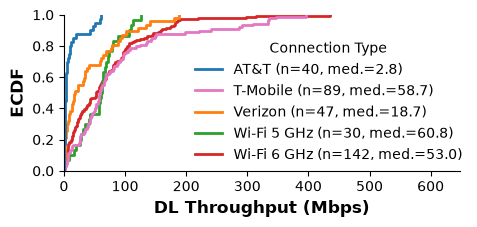

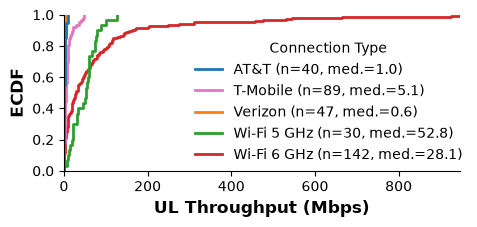

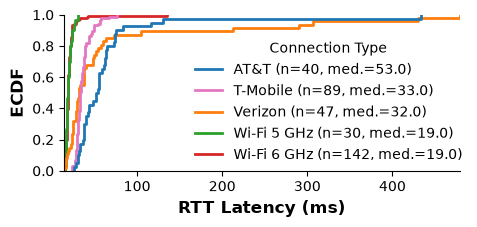

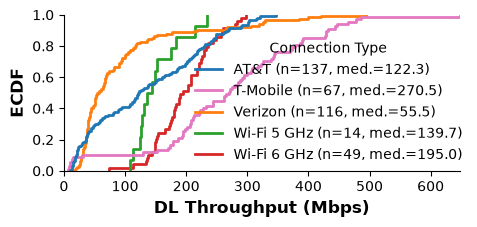

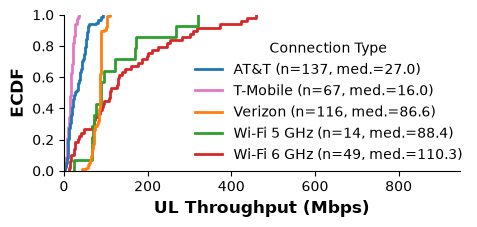

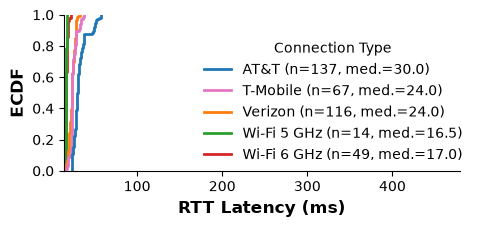

In [17]:
import pandas as pd

custom_palette = {
    'AT&T': 'C0',
    'T-Mobile': 'C6',
    'Verizon': 'C1',
    'Wi-Fi 5 GHz': 'C2',   
    'Wi-Fi 6 GHz': 'C3'
}

# =========================================================================
# 1. Pre-calculate the harmonized X-limits across BOTH dataframes
# =========================================================================
# Combine the two dataframes just to easily find the global min and max for the 'Bowl'
combined_df = pd.concat([
    df_ookla_scaled[df_ookla_scaled['Location'] == 'Bowl'], 
    df_ookla_pregame_scaled[df_ookla_pregame_scaled['Location'] == 'Bowl']
])

x_limits = {
    'DL Throughput (Mbps)': (combined_df['Download Speed'].min(), combined_df['Download Speed'].max()),
    'UL Throughput (Mbps)': (combined_df['Upload Speed'].min(), combined_df['Upload Speed'].max()),
    'RTT Latency (ms)': (combined_df['Latency'].min(), combined_df['Latency'].max())
}

# =========================================================================
# 2. Main Plotting Function
# =========================================================================
def plot_ookla_ecdfs(df, timing_prefix):
    df = df.copy()
    df['DL Throughput (Mbps)'] = df['Download Speed']
    df['UL Throughput (Mbps)'] = df['Upload Speed']
    df['RTT Latency (ms)'] = df['Latency']
    
    # Filter to Bowl only
    plot_df = df[df['Location'] == 'Bowl']
    sorted_operators = plot_df['Connection Type'].sort_values().unique().tolist()
    
    metrics = [
        ('DL Throughput (Mbps)', 'dl'),
        ('UL Throughput (Mbps)', 'ul'),
        ('RTT Latency (ms)', 'lat')
    ]
    
    for x_col, suffix in metrics:
        g = sns.displot(
            data=plot_df,
            x=x_col,
            hue='Connection Type',
            hue_order=sorted_operators,
            palette=custom_palette,  
            kind='ecdf',
            height=2.5,
            aspect=1.4,
            linewidth=2
        )

        # 3. Apply harmonized X-limits
        g.set(xlim=x_limits[x_col])
        g.set_axis_labels(x_col, "ECDF", fontsize=12, fontweight='bold')
        
        # 4. Modify the legend to include the median
        if g.legend:
            for text in g.legend.texts:
                label = text.get_text()
                # Ensure we are updating a category label (and not the legend title)
                if label in sorted_operators:
                    # Calculate the median for this specific connection type
                    median_val = plot_df[plot_df['Connection Type'] == label][x_col].median()
                    count_val = plot_df[plot_df['Connection Type'] == label][x_col].count()
                    # Append the median to the legend text (formatted to 1 decimal place)
                    text.set_text(f"{label} (n={count_val}, med.={median_val:.1f})")

        sns.move_legend(g, "center right", bbox_to_anchor=(1, 0.55))
        g.fig.tight_layout(rect=[0, 0.03, 1, 0.98])
        g.savefig(OUTPUT_DIR / f'ecdf_ookla_{timing_prefix}_bowl_{suffix}.pdf', dpi=300, bbox_inches='tight')
        plt.show()

# Execute the function for Game and Pregame DataFrames
plot_ookla_ecdfs(df_ookla_scaled, "game")
plot_ookla_ecdfs(df_ookla_pregame_scaled, "pregame")


In [18]:
# 1. Define your strict color mapping dictionary
# Update the keys to match exactly whatever strings are in your 'Connection Type' column
custom_palette = {
    'AT&T': 'C0',
    'T-Mobile': 'C6',
    'Verizon': 'C1',
    'Wi-Fi 5 GHz': 'C2',   
    'Wi-Fi 6 GHz': 'C3'
}


## Postgame

In [19]:
import numpy as np
import pandas as pd

# postgame sigcap on-off
df_postgame_sigcap_timing = pd.concat([
    pd.read_csv(DATA_DIR / 'postseason_sigcap_csv/2026_02_S26_1348_E26_1408Z-0500_indoor_Verizon_7c36e7df_sta_mr_timing_con_scoff.debug_wifi.csv', parse_dates=['timestamp']).assign(Scenario='Concourse - SigCap Off'),
    pd.read_csv(DATA_DIR / 'postseason_sigcap_csv/2026_02_S26_1411_E26_1419Z-0500_indoor_Verizon_7c36e7df_sta_mr_timing_con_scon.debug_wifi.csv', parse_dates=['timestamp']).assign(Scenario='Concourse - SigCap On'),
    pd.read_csv(DATA_DIR / 'postseason_sigcap_csv/2026_02_S26_1430_E26_1439Z-0500_outdoor_AT&T_fbd516f0_sta_mr_timing_bow_scoff.debug_wifi.csv', parse_dates=['timestamp']).assign(Scenario='Bowl - SigCap Off'),
    pd.read_csv(DATA_DIR / 'postseason_sigcap_csv/2026_02_S26_1440_E26_1448Z-0500_outdoor_AT&T_fbd516f0_sta_mr_timing_bow_scon.debug_wifi.csv', parse_dates=['timestamp']).assign(Scenario='Bowl - SigCap on'),
])

df_postgame_sigcap_timing_group = df_postgame_sigcap_timing[['timestamp', 'Scenario']].groupby('Scenario').agg(
    max=('timestamp', 'max'),
    min=('timestamp', 'min'),
)
display(df_postgame_sigcap_timing_group)

df_postgame_sigcap = pd.concat([
    pd.read_csv(DATA_DIR / 'postseason_sigcap_csv/2026_02_S26_1409_E26_1419Z-0500_indoor_T-Mobile_a0654bd3_sta_mr_wifi_con_scon.debug_wifi.csv', parse_dates=['timestamp']).assign(Scenario='Concourse - SigCap On'),
    pd.read_csv(DATA_DIR / 'postseason_sigcap_csv/2026_02_S26_1440_E26_1448Z-0500_outdoor_T-Mobile_a0654bd3_sta_mr_wifi_bow_scon.debug_wifi.csv', parse_dates=['timestamp']).assign(Scenario='Bowl - SigCap On'),
])

df_postgame_ookla = pd.read_csv(DATA_DIR / 'postseason_ookla_csv/ookla-sigcap-on-off-test.csv', parse_dates=['Date'], date_format='%m/%d/%Y, %I:%M %p')
# Assuming the local time of the Ookla test was US/Eastern
df_postgame_ookla['Date'] = df_postgame_ookla['Date'].dt.tz_localize('US/Eastern')

conditions = [
    df_postgame_ookla['Date'].between(row.min, row.max, inclusive='both')
    for row in df_postgame_sigcap_timing_group.itertuples()
]

choices = ['Concourse', 'Concourse', 'Bowl', 'Bowl']
df_postgame_ookla['Location'] = np.select(conditions, choices, default='unknown')

choices = ['no', 'yes', 'no', 'yes']
df_postgame_ookla['SigCap'] = np.select(conditions, choices, default='unknown')

df_postgame_ookla = df_postgame_ookla[df_postgame_ookla['Location'] != 'unknown']

print(f"Ookla data shapes: {df_postgame_ookla.shape}")
df_postgame_ookla.head()

,max,min
Scenario,,
Bowl - SigCap Off,2026-02-26 14:39:02.728000-05:00,2026-02-26 14:30:17.560000-05:00
Bowl - SigCap on,2026-02-26 14:48:57.526000-05:00,2026-02-26 14:40:11.901000-05:00
Concourse - SigCap Off,2026-02-26 14:08:05.861000-05:00,2026-02-26 13:48:45.349000-05:00
Concourse - SigCap On,2026-02-26 14:19:04.342000-05:00,2026-02-26 14:11:39.097000-05:00


Ookla data shapes: (35, 15)


,Date,ConnType,Lat,Lon,Download Speed,Download Size,Upload Speed,Upload Size,Latency,Server,InternalIp,ExternalIp,URL,Location,SigCap
16,2026-02-26 13:49:00-05:00,Wifi,41.698524,-86.234886,64.598088,79729890.0,110.872992,122232775.0,15,"South Bend, IN",10.12.79.156,66.205.174.156,https://www.speedtest.net/my-result/a/11456226593,Bowl,no
17,2026-02-26 13:50:00-05:00,Wifi,41.698511,-86.234880,80.864112,119148564.0,96.842968,109121385.0,15,"South Bend, IN",10.12.79.156,66.205.174.156,https://www.speedtest.net/my-result/a/11456228129,Bowl,no
18,2026-02-26 13:50:00-05:00,Wifi,41.698543,-86.234895,92.089760,131910338.0,123.012840,99762486.0,16,"South Bend, IN",10.12.79.156,66.205.174.156,https://www.speedtest.net/my-result/a/11456229491,Bowl,no
19,2026-02-26 13:51:00-05:00,Wifi,41.698532,-86.234895,78.107512,103892468.0,131.476336,121982460.0,16,"South Bend, IN",10.12.79.156,66.205.174.156,https://www.speedtest.net/my-result/a/11456230879,Bowl,no
20,2026-02-26 13:52:00-05:00,Wifi,41.698518,-86.234892,84.686896,97711140.0,172.404528,122881853.0,15,"South Bend, IN",10.12.79.156,66.205.174.156,https://www.speedtest.net/my-result/a/11456231974,Bowl,no


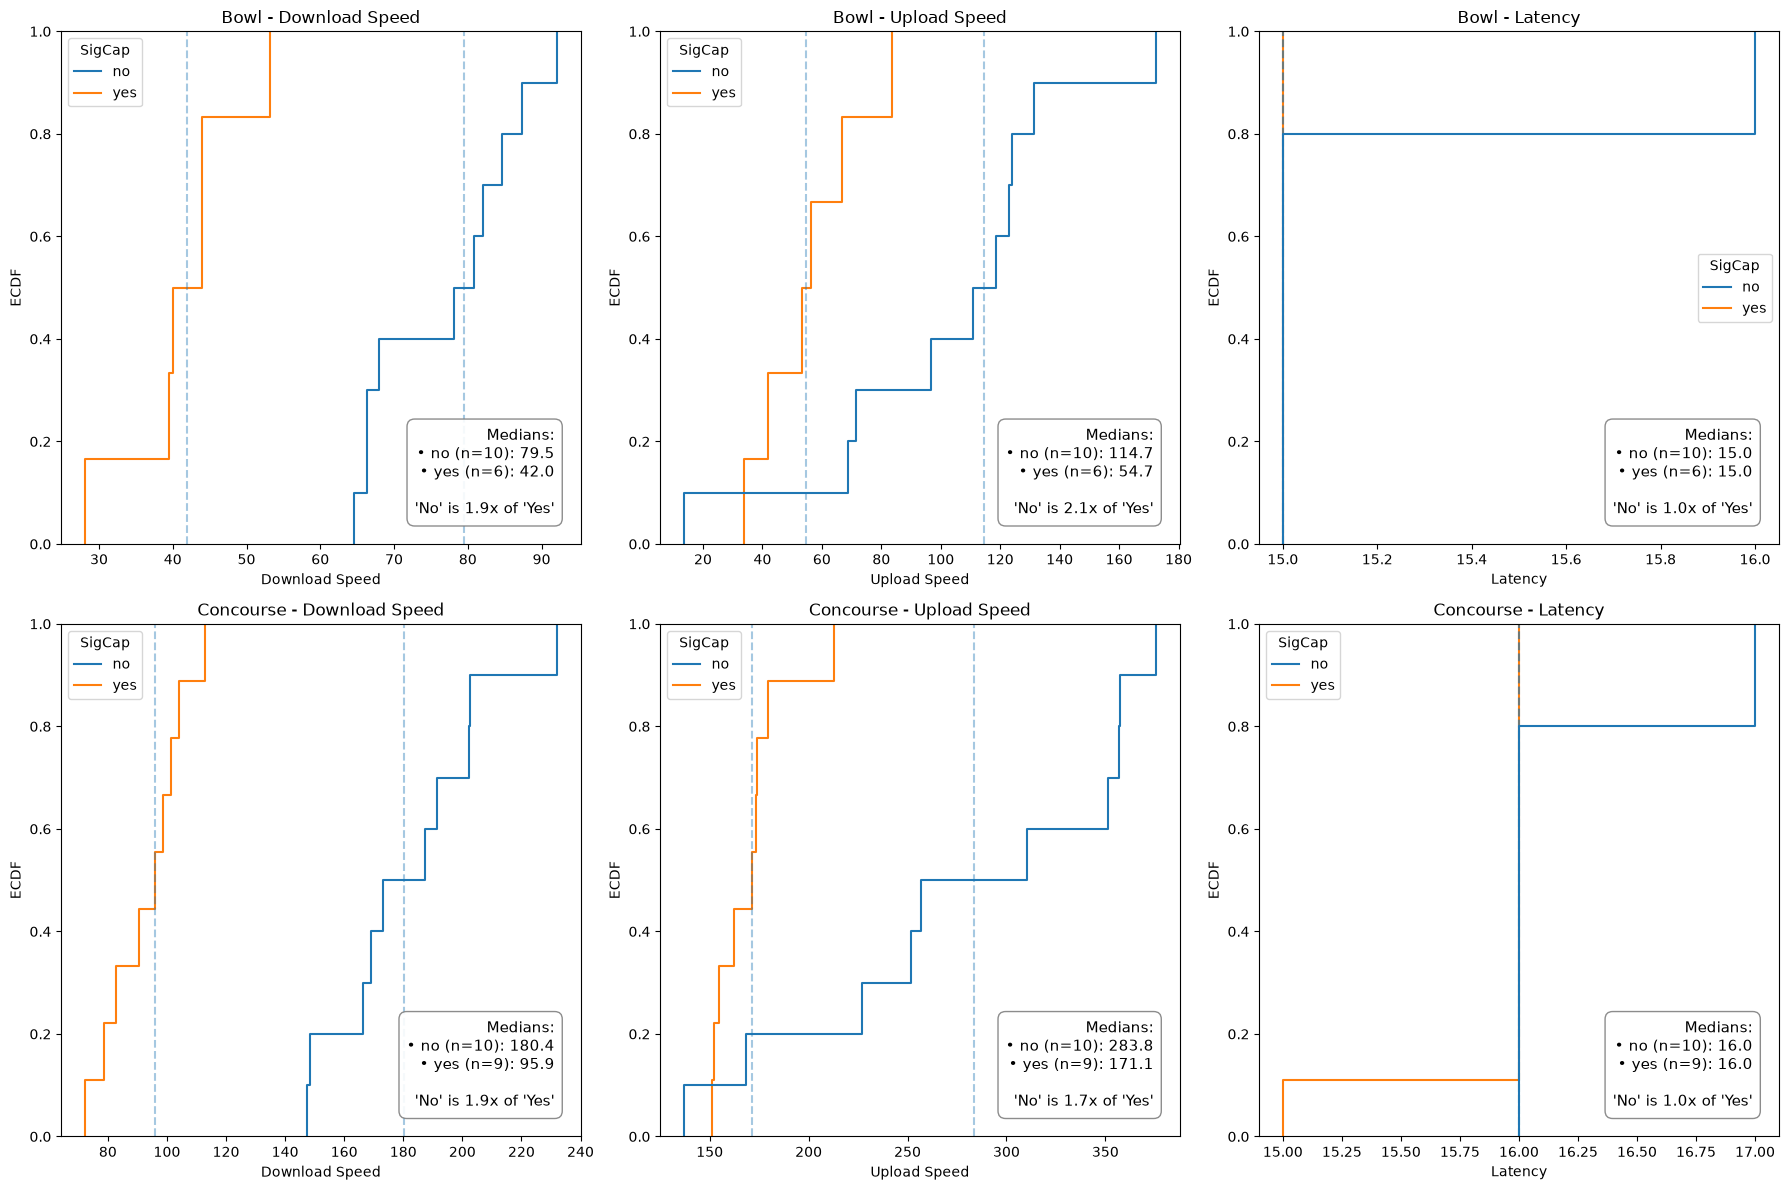

In [20]:

# Make sure these perfectly match your actual column names in df_postgame_ookla
metrics = ['Download Speed', 'Upload Speed', 'Latency']
locations = df_postgame_ookla['Location'].unique()

fig, axes = plt.subplots(
    nrows=len(locations), 
    ncols=len(metrics), 
    figsize=(18, 6 * len(locations))
)

# Ensure axes is 2D even if there's only 1 location
if len(locations) == 1:
    axes = [axes]

for i, location in enumerate(locations):
    df_subset = df_postgame_ookla[df_postgame_ookla['Location'] == location]
    
    for j, metric in enumerate(metrics):
        ax = axes[i][j]
        
        # 1. Plot the ECDF
        sns.ecdfplot(
            data=df_subset, 
            x=metric, 
            hue='SigCap', 
            ax=ax
        )
        ax.set_title(f"{location} - {metric}")
        ax.set_ylabel("ECDF")
        
        # 2. Calculate medians and counts (n) for the current location and metric
        medians = df_subset.groupby('SigCap')[metric].median()
        counts = df_subset.groupby('SigCap')[metric].count()
        
        # 3. Build the annotation text and add vertical lines
        annot_text = "Medians:\n"
        for sigcap_val, med_val in medians.items():
            n_val = counts[sigcap_val]
            annot_text += f"• {sigcap_val} (n={n_val}): {med_val:.1f}\n"
            # Draw a subtle dashed line at the median
            ax.axvline(med_val, linestyle='--', alpha=0.4)
            
        # 4. Calculate the ratio specifically for 'no' vs 'yes'
        med_dict_lower = {str(k).lower(): v for k, v in medians.items()}
        
        if 'no' in med_dict_lower and 'yes' in med_dict_lower:
            med_no = med_dict_lower['no']
            med_yes = med_dict_lower['yes']
            
            if med_yes > 0: # Avoid division by zero
                ratio = med_no / med_yes
                annot_text += f"\n'No' is {ratio:.1f}x of 'Yes'"
                
        # 5. Place a text box in the bottom right corner
        ax.text(
            0.95, 0.05, 
            annot_text.strip(),
            transform=ax.transAxes,
            fontsize=11,
            verticalalignment='bottom',
            horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray')
        )

plt.tight_layout()
plt.show()


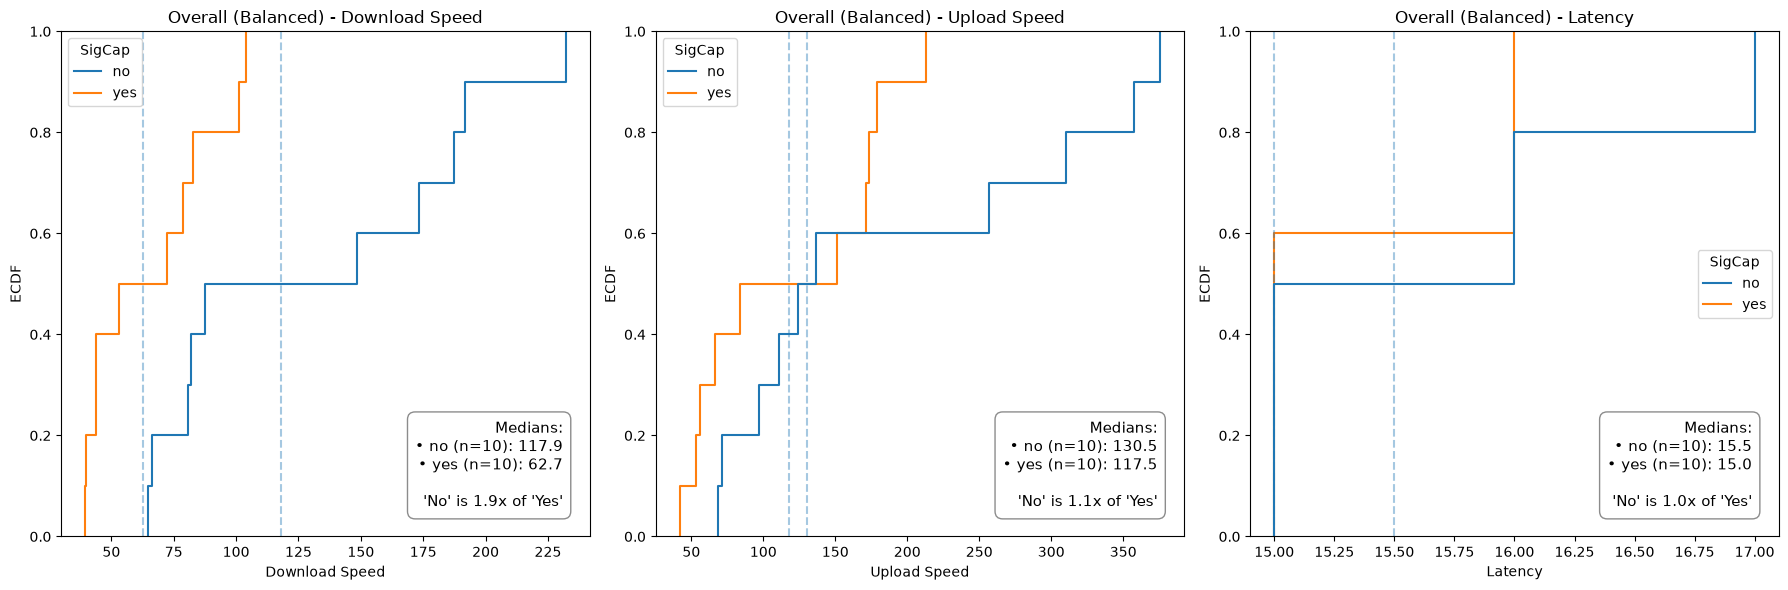

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ['Download Speed', 'Upload Speed', 'Latency']

# 1. Balance the dataset: randomly take 6 samples per Location and SigCap combination
df_balanced = (
    df_postgame_ookla
    .groupby(['Location', 'SigCap'])
    .sample(n=5, random_state=42) # random_state ensures reproducibility across notebook runs
)

# Create a single row of 3 subplots
fig, axes = plt.subplots(nrows=1, ncols=len(metrics), figsize=(18, 6))

for j, metric in enumerate(metrics):
    ax = axes[j]
    
    # 2. Plot the ECDF using the newly balanced dataframe
    sns.ecdfplot(
        data=df_balanced, 
        x=metric, 
        hue='SigCap', 
        ax=ax
    )
    ax.set_title(f"Overall (Balanced) - {metric}")
    ax.set_ylabel("ECDF")
    
    # 3. Calculate medians and counts for the metric across the balanced dataset
    medians = df_balanced.groupby('SigCap')[metric].median()
    counts = df_balanced.groupby('SigCap')[metric].count()
    
    # 4. Build the annotation text and add vertical lines
    annot_text = "Medians:\n"
    for sigcap_val, med_val in medians.items():
        n_val = counts[sigcap_val]
        annot_text += f"• {sigcap_val} (n={n_val}): {med_val:.1f}\n"
        ax.axvline(med_val, linestyle='--', alpha=0.4)
        
    # 5. Calculate the ratio specifically for 'no' vs 'yes'
    med_dict_lower = {str(k).lower(): v for k, v in medians.items()}
    
    if 'no' in med_dict_lower and 'yes' in med_dict_lower:
        med_no = med_dict_lower['no']
        med_yes = med_dict_lower['yes']
        
        if med_yes > 0: 
            ratio = med_no / med_yes
            annot_text += f"\n'No' is {ratio:.1f}x of 'Yes'"
            
    # 6. Place the text box
    ax.text(
        0.95, 0.05, 
        annot_text.strip(),
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='bottom',
        horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray')
    )

plt.tight_layout()
plt.show()


In [22]:
metrics = ['Download Speed', 'Upload Speed', 'Latency']

print("=== AVERAGE (MEAN) RATIOS ('No' / 'Yes') ===\n")

for metric in metrics:
    print(f"--- {metric} ---")
    
    # 1. Overall Combined Mean Ratio
    means_overall = df_balanced.groupby('SigCap')[metric].mean()
    means_dict_overall = {str(k).lower(): v for k, v in means_overall.items()}
    
    if 'no' in means_dict_overall and 'yes' in means_dict_overall and means_dict_overall['yes'] > 0:
        ratio_overall = means_dict_overall['no'] / means_dict_overall['yes']
        print(f"Overall Combined : {ratio_overall:.2f}x")
    
    # 2. Separated by Location Mean Ratios
    for location in df_balanced['Location'].unique():
        df_loc = df_balanced[df_balanced['Location'] == location]
        means_loc = df_loc.groupby('SigCap')[metric].mean()
        
        means_dict_loc = {str(k).lower(): v for k, v in means_loc.items()}
        
        if 'no' in means_dict_loc and 'yes' in means_dict_loc and means_dict_loc['yes'] > 0:
            ratio_loc = means_dict_loc['no'] / means_dict_loc['yes']
            print(f"  {location.ljust(15)}: {ratio_loc:.2f}x")
            
    print() # Blank line for readability


=== AVERAGE (MEAN) RATIOS ('No' / 'Yes') ===

--- Download Speed ---
Overall Combined : 1.99x
  Bowl           : 1.73x
  Concourse      : 2.13x

--- Upload Speed ---
Overall Combined : 1.61x
  Bowl           : 1.56x
  Concourse      : 1.62x

--- Latency ---
Overall Combined : 1.02x
  Bowl           : 1.00x
  Concourse      : 1.04x



# Ookla from QualiPoc

In [23]:
# import pandas as pd

# df_ookla_qp = pd.read_csv(DATA_DIR / '2025_all_qp_csv/app_ookla.csv', parse_dates=['Time'])
# df_ookla_qp = df_ookla_qp[
#     (df_ookla_qp['Collection'] == '20250828_preGame_Bowl') |
#     (df_ookla_qp['Collection'] == '20250913_Game_Bowl') |
#     (df_ookla_qp['Collection'] == '20250920_Game_Bowl')
# ].reset_index(drop=True)

In [24]:
# df_ookla_qp[['Collection', 'Operator', 'Test Status']].groupby(['Collection', 'Operator']).value_counts()

In [25]:
# df_ookla_qp.columns

# Wi-Fi deployments

In [26]:
import pandas as pd

df_sigcap_wifi_correction = pd.read_csv(
    DATA_DIR / 'game5_sigcap_csv/20251108_sigcap_bowl_wifi.csv', parse_dates=['timestamp']
).assign(game_label='Game', game_n_label='Game 5')
df_sigcap_wifi_correction = df_sigcap_wifi_correction[df_sigcap_wifi_correction['timestamp'] < '2025-11-08 21:38:42-0500']

df_sigcap_wifi = pd.concat([
    pd.read_csv(DATA_DIR / 'game1_sigcap_csv/20250913_sigcap_sta_wifi_bow.csv', parse_dates=['timestamp']).assign(game_label='Game', game_n_label='Game 1'),
    pd.read_csv(DATA_DIR / 'game2_sigcap_csv/20250920_sigcap_sta_wifi_bow.csv', parse_dates=['timestamp']).assign(game_label='Game', game_n_label='Game 2'),
    # pd.read_csv('game5_sigcap_csv/20251108_sigcap_bowl_wifi.csv', parse_dates=['timestamp']).assign(game_label='Game', game_n_label='Game 5'),
    pd.read_csv(DATA_DIR / 'game6_sigcap_csv/20251122_sigcap_bowl_wifi.csv', parse_dates=['timestamp']).assign(game_label='Game', game_n_label='Game 6'),
    pd.read_csv(DATA_DIR / 'preseason_sigcap_csv/20250828_SigCap_wifi_bow_s22.csv', parse_dates=['timestamp']).assign(game_label='Non-Game', game_n_label='Preseason'),
    pd.read_csv(DATA_DIR / 'postseason_sigcap_csv/2026_02_S26_1030_E26_1247Z-0500_outdoor_Verizon_7c36e7df_sta_mr_vzw_bow.debug_wifi.csv', parse_dates=['timestamp']).assign(game_label='Non-Game', game_n_label='Postseason'),
    pd.read_csv(DATA_DIR / 'postseason_sigcap_csv/2026_02_S26_1117_E26_1247Z-0500_outdoor_T-Mobile_a0654bd3_sta_at_tmo_bow.debug_wifi.csv', parse_dates=['timestamp']).assign(game_label='Non-Game', game_n_label='Postseason'),
    pd.read_csv(DATA_DIR / 'postseason_sigcap_csv/2026_02_S26_1124_E26_1246Z-0500_outdoor_AT&T_fbd516f0_sta_mr_att_bow.debug_wifi.csv', parse_dates=['timestamp']).assign(game_label='Non-Game', game_n_label='Postseason'),
    df_sigcap_wifi_correction
])

df_sigcap_wifi['freq_label'] = df_sigcap_wifi['primary_freq_mhz'].apply(
    lambda x: ('2.4' if x < 3000
                else '6' if x >= 5925
                else '5'))
df_sigcap_wifi['unii_label'] = df_sigcap_wifi['primary_freq_mhz'].apply(
    lambda x: ('2.4' if x < 3000
                else 'U-NII-1' if x > 5150 and x <= 5250
                else 'U-NII-2A' if x > 5250 and x <= 5350
                else 'U-NII-2B' if x > 5350 and x <= 5470
                else 'U-NII-2C' if x > 5470 and x <= 5725
                else 'U-NII-3' if x > 5725 and x <= 5850
                else 'U-NII-4' if x > 5850 and x <= 5925
                else 'U-NII-5' if x > 5925 and x <= 6425
                else 'U-NII-6' if x > 6425 and x <= 6525
                else 'U-NII-7' if x > 6525 and x <= 6875
                else 'U-NII-8' if x > 6875 and x <= 7125
                else 'unknown'))

df_sigcap_wifi.shape[0]


1794669

In [27]:
import pandas as pd

# from bokeh.models import WMTSTileSource
from bokeh.plotting import output_notebook

output_notebook()

def plot_rssi_map_bokeh(df):
    clean_df = df.dropna(subset=['latitude', 'longitude', 'rssi_dbm']).copy()
    clean_df = clean_df[(clean_df['latitude'] != 0) & (clean_df['longitude'] != 0)]

    # Reproject WGS84 -> Web Mercator
    gdf = gpd.GeoDataFrame(
        clean_df, 
        geometry=gpd.points_from_xy(clean_df['longitude'], clean_df['latitude']), 
        crs="EPSG:4326"
    ).to_crs("EPSG:3857")
    
    gdf['x'] = gdf.geometry.x
    gdf['y'] = gdf.geometry.y

    p = figure(
        title="WiFi RSSI Footprint Map",
        x_axis_type="mercator",
        y_axis_type="mercator",
        width=950,
        height=600,
        tools="pan,reset,save",
        x_range=(gdf['x'].min() - 100, gdf['x'].max() + 100),
        y_range=(gdf['y'].min() - 100, gdf['y'].max() + 100)
    )

    zoom_tool = WheelZoomTool(zoom_on_axis=False)
    p.add_tools(zoom_tool)
    p.toolbar.active_scroll = zoom_tool

    # Add CartoDB Light Tile Source
    osm_tile = WMTSTileSource(
        url='https://cartodb-basemaps-4.global.ssl.fastly.net/light_all/{Z}/{X}/{Y}.png',
        attribution="© CartoDB contributors"
    )
    p.add_tile(osm_tile)

    # Color mapping for RSSI
    color_mapper = LinearColorMapper(
        palette=Viridis256,
        low=gdf['rssi_dbm'].min(),
        high=gdf['rssi_dbm'].max()
    )

    cols = ['x', 'y', 'timestamp', 'longitude', 'latitude', 'rssi_dbm', 'ssid', 'freq_label', 'game_n_label']
    cols = [c for c in cols if c in gdf.columns]
    source = ColumnDataSource(gdf[cols].to_dict(orient="list"))

    p.scatter(
        x='x', y='y', size=6, source=source,
        fill_color={'field': 'rssi_dbm', 'transform': color_mapper},
        line_color=None, fill_alpha=0.8
    )

    color_bar = ColorBar(
        color_mapper=color_mapper,
        label_standoff=12,
        location=(0, 0),
        title='RSSI (dBm)'
    )
    p.add_layout(color_bar, 'right')

    hover = HoverTool(tooltips=[
        ("Lat/Lon", "@latitude, @longitude"),
        ("RSSI (dBm)", "@rssi_dbm"),
        ("SSID", "@ssid"),
        ("Band", "@freq_label GHz"),
        ("Game", "@game_n_label"),
        ("Timestamp", "@timestamp{%Y-%m-%d %H:%M:%S}")
    ], formatters={'@timestamp': 'datetime'})
    p.add_tools(hover)

    show(p)

# Call on df_sigcap_wifi
plot_rssi_map_bokeh(
    df_sigcap_wifi[
        (df_sigcap_wifi["freq_label"] == "6")
        & (df_sigcap_wifi["game_n_label"] == "Postseason")
        & (df_sigcap_wifi["ssid"].str.contains("ND-guest"))
        & (df_sigcap_wifi['primary_ch_num'] == 5)
        & (df_sigcap_wifi["6ghz_ap_type"] == "SP")
    ]
)


Loading BokehJS ...

    primary_ch_num  bssid
0              1.0      1
1              5.0    276
2              9.0      9
3             13.0      6
4             17.0      7
5             21.0    281
6             25.0      2
7             29.0      6
8             33.0      5
9             37.0    278
10            41.0      4
11            45.0      5
12            49.0      5
13            53.0    249
14            57.0      5
15            61.0      6
16            65.0      5
17            69.0    262
18            73.0     16
19            77.0      3
20            81.0      4
21            85.0    238
22            89.0      7
23            93.0      7
24           101.0      0
25           117.0      0
26           129.0      5
27           133.0    262
28           137.0      7
29           141.0      7
30           145.0     41
31           149.0    273
32           153.0      4
33           157.0      5
34           161.0      3
35           165.0    234
36           169.0      7
37          

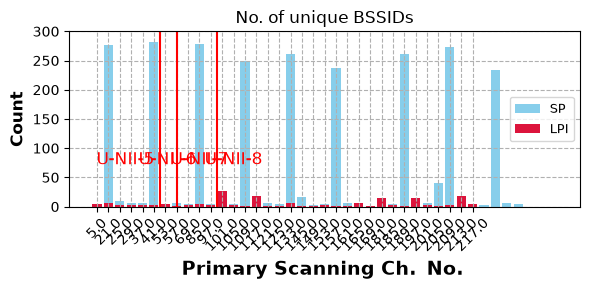

In [28]:
import matplotlib.pyplot as plt
import numpy as np

chlist = [5, 21, 37, 53, 69, 85, 101, 117, 133, 149, 165, 181, 197, 213]

sigcap_focus = df_sigcap_wifi[
    (df_sigcap_wifi["freq_label"] == "6")
    & (df_sigcap_wifi["6ghz_ap_type"] == "LPI")
    & (df_sigcap_wifi["ssid"].str.contains("ND-guest"))
]

bar_data_lpi = sigcap_focus[["bssid", "primary_ch_num"]].groupby("primary_ch_num")["bssid"].nunique().reset_index()
for value in chlist:
    if value not in bar_data_lpi["primary_ch_num"].values:
        bar_data_lpi = pd.concat(
            [bar_data_lpi, pd.DataFrame({"primary_ch_num": [value], "bssid": [0]})],
            ignore_index=True
        ).sort_values("primary_ch_num")
# print(bar_data_lpi)

sigcap_focus = df_sigcap_wifi[
    (df_sigcap_wifi["freq_label"] == "6")
    & (df_sigcap_wifi["6ghz_ap_type"] == "SP")
    & (df_sigcap_wifi["ssid"].str.contains("ND-guest"))
]

bar_data_sp = sigcap_focus[["bssid", "primary_ch_num"]].groupby("primary_ch_num")["bssid"].nunique().reset_index()
for value in chlist:
    if value not in bar_data_sp["primary_ch_num"].values:
        bar_data_sp = pd.concat(
            [bar_data_sp, pd.DataFrame({"primary_ch_num": [value], "bssid": [0]})],
            ignore_index=True
        ).sort_values("primary_ch_num")
print(bar_data_sp)
print(bar_data_sp["bssid"].sum())


fig, ax = plt.subplots(figsize=(6, 3))

ax.bar(np.arange(0, bar_data_sp.shape[0]), bar_data_sp["bssid"], color='skyblue', label="SP")
ax.bar(np.arange(0, bar_data_lpi.shape[0]), bar_data_lpi["bssid"], color='crimson', label="LPI")

limit = plt.ylim()
label_y = .85 * limit[1]

ax.set_xlabel(r'$\mathbf{Primary\ Scanning\ Ch.\ No.}$', fontsize=14)
ax.set_ylabel(r'$\mathbf{Count}$', fontsize=12)
ax.text(2.5, 80, 'U-NII-5', fontsize=12, color='r', ha='center', va='center')
ax.axvline(x=5.5, color='r', linestyle='-')
ax.text(6.2, 80, 'U-NII-6', fontsize=12, color='r', ha='center', va='center')
ax.axvline(x=7, color='r', linestyle='-')
ax.text(9, 80, 'U-NII-7', fontsize=12, color='r', ha='center', va='center')
ax.axvline(x=10.5, color='r', linestyle='-')
ax.text(12, 80, 'U-NII-8', fontsize=12, color='r', ha='center', va='center')
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle='--', which='both', axis='both')
plt.title("No. of unique BSSIDs")
# plt.yticks(np.arange(0, 700, 200), fontsize=20, rotation=45)
plt.xticks(np.arange(0, bar_data_lpi.shape[0]), bar_data_lpi["primary_ch_num"], fontsize=10, rotation=45)
plt.legend(fontsize=9, loc='center right')
plt.ylim(0,300)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bar_plot_unique_bssid_bowl.pdf", bbox_inches='tight')
plt.show()
plt.close()

In [29]:
df_sigcap_wifi[
    (df_sigcap_wifi["freq_label"] == "6")
    & (df_sigcap_wifi["game_n_label"] == "Postseason")
    & (df_sigcap_wifi["ssid"].str.contains("ND-guest"))
    & (df_sigcap_wifi['primary_ch_num'] == 145)
    & (df_sigcap_wifi["6ghz_ap_type"] == "SP")
][['alphanumeric_ap_name', 'primary_freq_mhz']]

,alphanumeric_ap_name,primary_freq_mhz
250,stad0616-a-s114-115-rvom,6675.0
251,stad0453-b-s21-22-r3,6675.0
261,stad0448-b-s19-20-r33,6675.0
266,stad0451-b-s19-20-r3,6675.0
288,stad0541-a-s24-25-rvom,6675.0
...,...,...
891768,stad0857-b-s11-12-r43,6675.0
891829,stad0569-a-s28-29-r38,6675.0
891900,stad0647-a-s13-14-r33,6675.0
891966,stad0453-b-s21-22-r3,6675.0


In [30]:
df_sigcap_wifi[
    (df_sigcap_wifi["freq_label"] == "6")
    & (df_sigcap_wifi["game_n_label"] == "Postseason")
    & (df_sigcap_wifi["ssid"].str.contains("ND-guest"))
    & (df_sigcap_wifi['primary_ch_num'] == 145)
    & (df_sigcap_wifi["6ghz_ap_type"] == "SP")
][['bssid']].value_counts()

bssid            
98:8f:00:87:7e:44    1210
98:8f:00:88:9d:e4    1158
98:8f:00:88:7a:a4    1145
98:8f:00:88:9d:b4    1145
98:8f:00:89:49:44    1141
98:8f:00:88:c1:24    1046
98:8f:00:87:5c:e4    1027
98:8f:00:88:70:84    1019
98:8f:00:89:5d:e4    1009
98:8f:00:87:61:94     972
98:8f:00:87:82:f4     909
98:8f:00:89:71:f4     896
98:8f:00:88:1b:34     880
98:8f:00:87:a4:e4     863
98:8f:00:87:78:14     858
98:8f:00:88:8b:e4     844
98:8f:00:89:3a:d4     765
98:8f:00:87:f7:94     762
98:8f:00:88:0d:84     710
98:8f:00:88:ac:24     674
98:8f:00:88:91:54     615
98:8f:00:87:42:44     504
98:8f:00:89:1b:54     474
98:8f:00:88:9c:c4     468
98:8f:00:89:0d:74     463
98:8f:00:89:17:94     445
98:8f:00:87:b8:c4     414
98:8f:00:87:79:04     411
98:8f:00:88:82:54     361
98:8f:00:88:fa:24     314
98:8f:00:87:c8:e4     303
98:8f:00:88:b9:d4     263
98:8f:00:89:35:c4     261
98:8f:00:88:f0:04     246
98:8f:00:88:19:84     239
98:8f:00:87:ca:34     226
98:8f:00:88:2e:84     171
98:8f:00:88:03:f4   

59
279


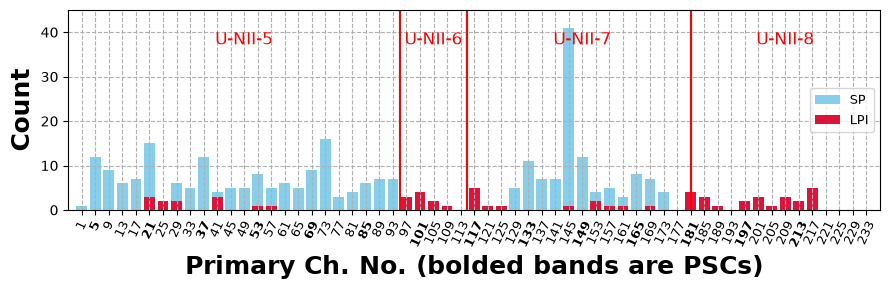

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import AutoLocator

chlist = [1, 5, 9, 13, 17, 21, 25, 29, 33, 37, 41, 45, 49, 53, 57, 61, 65, 69, 73, 77,
          81, 85, 89, 93, 97, 101, 105, 109, 113, 117, 121, 125, 129, 133, 137, 141, 145,
          149, 153, 157, 161, 165, 169, 173, 177, 181, 185, 189, 193, 197, 201, 205, 209,
          213, 217, 221, 225, 229, 233]
chlist_psc = [5, 21, 37, 53, 69, 85, 101, 117, 133, 149, 165, 181, 197, 213]


sigcap_focus = df_sigcap_wifi[
    (df_sigcap_wifi["freq_label"] == "6")
    & (df_sigcap_wifi["game_n_label"] == "Postseason")
    & (df_sigcap_wifi["ssid"].str.contains("ND-guest"))
].copy()
sigcap_focus['primary_ch_num'] = sigcap_focus['primary_ch_num'].astype(int)

bar_data_lpi = sigcap_focus[
    (sigcap_focus["6ghz_ap_type"] == "LPI")
][["bssid", "primary_ch_num"]].groupby("primary_ch_num")["bssid"].nunique().reset_index()
for value in chlist:
    if value not in bar_data_lpi["primary_ch_num"].values:
        bar_data_lpi = pd.concat(
            [bar_data_lpi, pd.DataFrame({"primary_ch_num": [value], "bssid": [0]})],
            ignore_index=True
        ).sort_values("primary_ch_num")
# print(bar_data_lpi)
print(bar_data_lpi["bssid"].sum())

bar_data_sp = sigcap_focus[
    (sigcap_focus["6ghz_ap_type"] == "SP")
][["bssid", "primary_ch_num"]].groupby("primary_ch_num")["bssid"].nunique().reset_index()
for value in chlist:
    if value not in bar_data_sp["primary_ch_num"].values:
        bar_data_sp = pd.concat(
            [bar_data_sp, pd.DataFrame({"primary_ch_num": [value], "bssid": [0]})],
            ignore_index=True
        ).sort_values("primary_ch_num")
# print(bar_data_sp)
print(bar_data_sp["bssid"].sum())


fig, ax = plt.subplots(figsize=(9, 3))

ax.bar(np.arange(0, bar_data_sp.shape[0]), bar_data_sp["bssid"], color='skyblue', label="SP")
ax.bar(np.arange(0, bar_data_lpi.shape[0]), bar_data_lpi["bssid"], color='crimson', label="LPI")

limit = 45
label_y = .85 * limit

ax.set_xlabel('Primary Ch. No. (bolded bands are PSCs)', fontsize=18, weight='bold')
ax.set_ylabel('Count', fontsize=18, weight='bold')
ax.text(12, label_y, 'U-NII-5', fontsize=12, color='r', ha='center', va='center')
ax.axvline(x=23.5, color='r', linestyle='-')
ax.text(26, label_y, 'U-NII-6', fontsize=12, color='r', ha='center', va='center')
ax.axvline(x=28.5, color='r', linestyle='-')
ax.text(37, label_y, 'U-NII-7', fontsize=12, color='r', ha='center', va='center')
ax.axvline(x=45, color='r', linestyle='-')
ax.text(52, label_y, 'U-NII-8', fontsize=12, color='r', ha='center', va='center')
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle='--', which='both', axis='both')
# plt.title("No. of Unique BSSIDs on 2026 Non-Game Campaign")
# plt.yticks(np.arange(0, 700, 200), fontsize=20, rotation=45)

# 1. Set the xticks normally
plt.xticks(np.arange(0, bar_data_lpi.shape[0]), chlist, fontsize=9, rotation=65)

# 2. Iterate through the drawn labels and make PSC channels bold
for tick_label in ax.get_xticklabels():
    # Convert the label text back to integer to check against chlist_psc
    if int(tick_label.get_text()) in chlist_psc:
        tick_label.set_fontweight('bold')


plt.legend(fontsize=9, loc='center right')
plt.xlim(-1, len(chlist))
plt.ylim(0, limit)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bar_plot_unique_bssid_bowl_2026.pdf", bbox_inches='tight')
plt.show()
plt.close()

114
2293


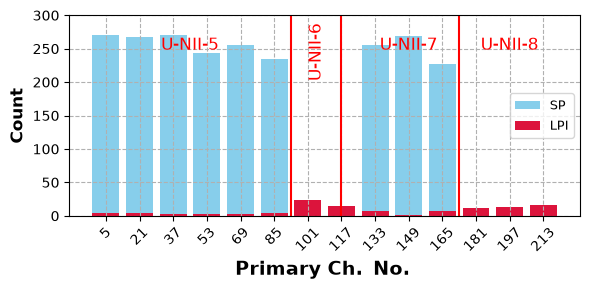

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import AutoLocator

chlist = [5, 21, 37, 53, 69, 85, 101, 117, 133, 149, 165, 181, 197, 213]

sigcap_focus = df_sigcap_wifi[
    (df_sigcap_wifi["freq_label"] == "6")
    & (df_sigcap_wifi["game_n_label"] != "Postseason")
    & (df_sigcap_wifi["ssid"].str.contains("ND-guest"))
].copy()
sigcap_focus['primary_ch_num'] = sigcap_focus['primary_ch_num'].astype(int)

bar_data_lpi = sigcap_focus[
    (sigcap_focus["6ghz_ap_type"] == "LPI")
][["bssid", "primary_ch_num"]].groupby("primary_ch_num")["bssid"].nunique().reset_index()
for value in chlist:
    if value not in bar_data_lpi["primary_ch_num"].values:
        bar_data_lpi = pd.concat(
            [bar_data_lpi, pd.DataFrame({"primary_ch_num": [value], "bssid": [0]})],
            ignore_index=True
        ).sort_values("primary_ch_num")
# print(bar_data_lpi)
print(bar_data_lpi["bssid"].sum())

bar_data_sp = sigcap_focus[
    (sigcap_focus["6ghz_ap_type"] == "SP")
][["bssid", "primary_ch_num"]].groupby("primary_ch_num")["bssid"].nunique().reset_index()
for value in chlist:
    if value not in bar_data_sp["primary_ch_num"].values:
        bar_data_sp = pd.concat(
            [bar_data_sp, pd.DataFrame({"primary_ch_num": [value], "bssid": [0]})],
            ignore_index=True
        ).sort_values("primary_ch_num")
# print(bar_data_sp)
print(bar_data_sp["bssid"].sum())


fig, ax = plt.subplots(figsize=(6, 3))

ax.bar(np.arange(0, bar_data_sp.shape[0]), bar_data_sp["bssid"], color='skyblue', label="SP")
ax.bar(np.arange(0, bar_data_lpi.shape[0]), bar_data_lpi["bssid"], color='crimson', label="LPI")

limit = 300
label_y = .85 * limit

ax.set_xlabel(r'$\mathbf{Primary\ Ch.\ No.}$', fontsize=14)
ax.set_ylabel(r'$\mathbf{Count}$', fontsize=12)
ax.text(2.5, label_y, 'U-NII-5', fontsize=12, color='r', ha='center', va='center')
ax.axvline(x=5.5, color='r', linestyle='-')
ax.text(6.25, label_y - 10, 'U-NII-6', fontsize=12, color='r', ha='center', va='center', rotation=90)
ax.axvline(x=7, color='r', linestyle='-')
ax.text(9, label_y, 'U-NII-7', fontsize=12, color='r', ha='center', va='center')
ax.axvline(x=10.5, color='r', linestyle='-')
ax.text(12, label_y, 'U-NII-8', fontsize=12, color='r', ha='center', va='center')
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle='--', which='both', axis='both')
# plt.title("No. of Unique BSSIDs on 2025 Campaigns")
# plt.yticks(np.arange(0, 700, 200), fontsize=20, rotation=45)
plt.xticks(np.arange(0, bar_data_lpi.shape[0]), bar_data_lpi["primary_ch_num"], fontsize=10, rotation=45)
plt.legend(fontsize=9, loc='center right')
plt.ylim(0, limit)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bar_plot_unique_bssid_bowl_2025.pdf", bbox_inches='tight')
plt.show()
plt.close()

In [33]:
df_sigcap_wifi.columns

Index(['timestamp', 'sigcap_version', 'android_version', 'is_debug', 'uuid',
       'device_name', 'latitude', 'longitude', 'altitude', 'hor_acc',
       'ver_acc', 'network_type*', 'ssid', 'bssid', 'primary_freq_mhz',
       'center_freq_mhz', 'width_mhz', 'channel_num', 'primary_ch_num',
       'rssi_dbm', 'standard', 'connected', 'link_speed', 'tx_link_speed',
       'rx_link_speed', 'max_supported_tx_link_speed',
       'max_supported_rx_link_speed', 'capabilities', 'sta_count', 'ch_util',
       'tx_power_dbm', 'link_margin_db', 'alphanumeric_ap_name',
       '6ghz_ap_type', 'game_label', 'game_n_label', 'manufacturer',
       'wifi_beacon_unix_timestamp_ms', 'reg_info_int', 'freq_label',
       'unii_label'],
      dtype='str')

,game_label,ap_category,bssid
0,Game,5 GHz,1819
1,Game,6 GHz LPI,66
2,Game,6 GHz SP,719
3,Non-Game,5 GHz,1736
4,Non-Game,6 GHz LPI,60
5,Non-Game,6 GHz SP,700


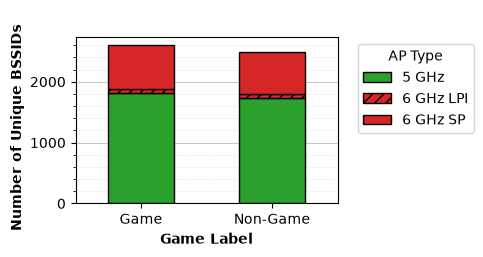

In [34]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

# 1. Filter for 'ND-guest' and only freq_label 5 and 6
filtered_df = df_sigcap_wifi[
    (df_sigcap_wifi['ssid'].str.contains('ND-guest', na=False)) & 
    (df_sigcap_wifi['freq_label'].isin(['5', '6']))
][['freq_label', 'bssid', 'game_label', '6ghz_ap_type']].copy()

# 2. Remove 'unknown' 6ghz_ap_type when freq_label is 6
filtered_df = filtered_df[
    ~((filtered_df['freq_label'] == '6') & (filtered_df['6ghz_ap_type'] == 'unknown'))
]

# 3. Create a unified category column for the legend
def get_ap_category(row):
    if str(row['freq_label']) == '5':
        return '5 GHz'
    elif str(row['freq_label']) == '6':
        # Safely handling case insensitivity just in case
        ap_type = str(row['6ghz_ap_type']).upper()
        if ap_type == 'LPI':
            return '6 GHz LPI'
        elif ap_type == 'SP':
            return '6 GHz SP'
        else:
            return f"6 GHz {row['6ghz_ap_type']}"
    return 'Unknown'

filtered_df['ap_category'] = filtered_df.apply(get_ap_category, axis=1)

# 4. Group by game_label and our new ap_category, then get unique BSSID counts
# Specifying ['bssid'] ensures we only count unique BSSIDs 
bssid_counts = filtered_df.groupby(['game_label', 'ap_category'])['bssid'].nunique().reset_index()
display(bssid_counts)

# 5. Pivot the dataframe
bssid_pivot = bssid_counts.pivot(index='game_label', columns='ap_category', values='bssid')

# Ensure the column order is predictable so colors and hatches align correctly
ordered_cols = ['5 GHz', '6 GHz LPI', '6 GHz SP']
# Keep only the columns that actually exist in your dataset
existing_cols = [c for c in ordered_cols if c in bssid_pivot.columns]
bssid_pivot = bssid_pivot[existing_cols]

# Define your harmonized colors
color_map = {
    '5 GHz': 'C2',      # Blue
    '6 GHz LPI': 'C3',  # Orange
    '6 GHz SP': 'C3'    # Orange (Harmonized)
}
colors = [color_map[c] for c in existing_cols]

# Define your fill patterns (hatches)
# '' is solid, '///' is diagonal lines (you can also use 'xxx', '\\\\', '---', etc.)
hatch_map = {
    '5 GHz': '',         
    '6 GHz LPI': '///',     
    '6 GHz SP': ''    
}
hatches = [hatch_map[c] for c in existing_cols]

# 6. Create the stacked bar plot
ax = bssid_pivot.plot(
    kind='bar', 
    stacked=True, 
    figsize=(5, 2.4), 
    color=colors,
    edgecolor='black' # Black outlines make hatches much easier to see
)

# 7. Apply hatches to the drawn bars
bars_per_category = len(bssid_pivot)
for i, bar in enumerate(ax.patches):
    # Determine which column (category) this bar belongs to
    col_idx = i // bars_per_category
    bar.set_hatch(hatches[col_idx])

# 8. Create custom legend handles to show the hatches accurately
handles = []
for col in existing_cols:
    patch = mpatches.Patch(
        facecolor=color_map[col], 
        hatch=hatch_map[col], 
        edgecolor='black', # Ensure the hatch is clearly visible
        label=col
    )
    handles.append(patch)

# 9. Add Y-axis major and minor grid lines
# Enable minor ticks on the y-axis
ax.yaxis.set_minor_locator(AutoMinorLocator())
# Customize the major grid (solid, darker lines)
ax.grid(which='major', axis='y', linestyle='-', linewidth=0.75, alpha=0.7)
# Customize the minor grid (dotted, lighter lines)
ax.grid(which='minor', axis='y', linestyle=':', linewidth=0.5, alpha=0.5)
# Place the grid lines behind the bars
ax.set_axisbelow(True)

# plt.title('Unique BSSIDs for ND-guest by Game')
plt.xlabel('Game Label', weight='bold')
plt.ylabel('Number of Unique BSSIDs   ', weight='bold')
# Pass our custom handles directly into the legend
plt.legend(handles=handles, title='AP Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "stacked_bar_unique_bssid_bowl.pdf", bbox_inches='tight')
plt.show()



,game_label,ap_category,bssid
0,Game,5 GHz,1819
1,Game,6 GHz LPI,66
2,Game,6 GHz SP,719
3,Non-Game,5 GHz,1736
4,Non-Game,6 GHz LPI,60
5,Non-Game,6 GHz SP,700


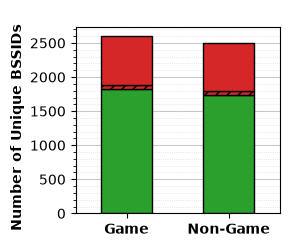

In [35]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# 1. Filter for 'ND-guest' and only freq_label 5 and 6
filtered_df = df_sigcap_wifi[
    (df_sigcap_wifi['ssid'].str.contains('ND-guest', na=False)) & 
    (df_sigcap_wifi['freq_label'].isin(['5', '6']))
][['freq_label', 'bssid', 'game_label', '6ghz_ap_type']].copy()

# 2. Remove 'unknown' 6ghz_ap_type when freq_label is 6
filtered_df = filtered_df[
    ~((filtered_df['freq_label'] == '6') & (filtered_df['6ghz_ap_type'] == 'unknown'))
]

# 3. Create a unified category column for the legend
def get_ap_category(row):
    if str(row['freq_label']) == '5':
        return '5 GHz'
    elif str(row['freq_label']) == '6':
        # Safely handling case insensitivity just in case
        ap_type = str(row['6ghz_ap_type']).upper()
        if ap_type == 'LPI':
            return '6 GHz LPI'
        elif ap_type == 'SP':
            return '6 GHz SP'
        else:
            return f"6 GHz {row['6ghz_ap_type']}"
    return 'Unknown'

filtered_df['ap_category'] = filtered_df.apply(get_ap_category, axis=1)

# 4. Group by game_label and our new ap_category, then get unique BSSID counts
# Specifying ['bssid'] ensures we only count unique BSSIDs 
bssid_counts = filtered_df.groupby(['game_label', 'ap_category'])['bssid'].nunique().reset_index()
display(bssid_counts)

# 5. Pivot the dataframe
bssid_pivot = bssid_counts.pivot(index='game_label', columns='ap_category', values='bssid')

# Ensure the column order is predictable so colors and hatches align correctly
ordered_cols = ['5 GHz', '6 GHz LPI', '6 GHz SP']
# Keep only the columns that actually exist in your dataset
existing_cols = [c for c in ordered_cols if c in bssid_pivot.columns]
bssid_pivot = bssid_pivot[existing_cols]

# Define your harmonized colors
color_map = {
    '5 GHz': 'C2',      # Blue
    '6 GHz LPI': 'C3',  # Orange
    '6 GHz SP': 'C3'    # Orange (Harmonized)
}
colors = [color_map[c] for c in existing_cols]

# Define your fill patterns (hatches)
# '' is solid, '///' is diagonal lines (you can also use 'xxx', '\\\\', '---', etc.)
hatch_map = {
    '5 GHz': '',         
    '6 GHz LPI': '///',     
    '6 GHz SP': ''    
}
hatches = [hatch_map[c] for c in existing_cols]

# 6. Create the stacked bar plot
ax = bssid_pivot.plot(
    kind='bar', 
    stacked=True, 
    figsize=(3, 2.4), 
    color=colors,
    edgecolor='black' # Black outlines make hatches much easier to see
)

# 7. Apply hatches to the drawn bars
bars_per_category = len(bssid_pivot)
for i, bar in enumerate(ax.patches):
    # Determine which column (category) this bar belongs to
    col_idx = i // bars_per_category
    bar.set_hatch(hatches[col_idx])

# 8. Create custom legend handles to show the hatches accurately
handles = []
for col in existing_cols:
    patch = mpatches.Patch(
        facecolor=color_map[col], 
        hatch=hatch_map[col], 
        edgecolor='black', # Ensure the hatch is clearly visible
        label=col
    )
    handles.append(patch)

# 9. Add Y-axis major and minor grid lines
# Enable minor ticks on the y-axis
ax.yaxis.set_minor_locator(AutoMinorLocator())
# Customize the major grid (solid, darker lines)
ax.grid(which='major', axis='y', linestyle='-', linewidth=0.75, alpha=0.7)
# Customize the minor grid (dotted, lighter lines)
ax.grid(which='minor', axis='y', linestyle=':', linewidth=0.5, alpha=0.5)
# Place the grid lines behind the bars
ax.set_axisbelow(True)

# plt.title('Unique BSSIDs for ND-guest by Game')
plt.xlabel('', weight='bold')
plt.ylabel('Number of Unique BSSIDs   ', weight='bold')
# no legend
ax.get_legend().remove()
plt.xticks(rotation=0, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "stacked_bar_unique_bssid_bowl_alt.pdf", bbox_inches='tight')
plt.show()



,freq_label,game_n_label,ap_source,unique_bssid_count
0,5,Game 1,Other AP,246
1,5,Game 1,Stadium AP,1334
2,5,Game 2,Other AP,225
3,5,Game 2,Stadium AP,1391
4,5,Game 5,Other AP,225
5,5,Game 5,Stadium AP,1172
6,5,Game 6,Other AP,229
7,5,Game 6,Stadium AP,1289
8,5,Postseason,Other AP,323
9,5,Postseason,Stadium AP,1402


ap_source                Other AP  Stadium AP
game_n_label freq_label                      
Game 1       5              246.0      1334.0
             6               83.0       310.0
Game 2       5              225.0      1391.0
             6              101.0       436.0
Game 5       5              225.0      1172.0
             6               78.0       551.0
Game 6       5              229.0      1289.0
             6               96.0       593.0
Postseason   5              323.0      1402.0
             6               85.0       262.0
Preseason    5              110.0       729.0
             6              696.0         0.0

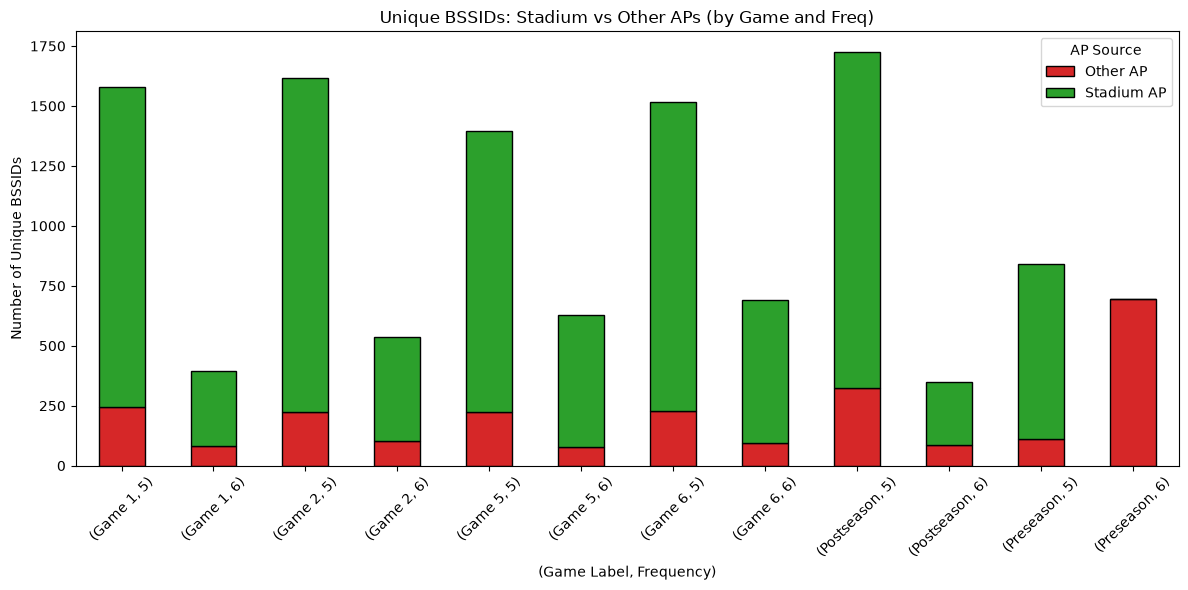

In [36]:
import matplotlib.pyplot as plt

# 1. Filter the dataset and include 'bssid' for unique counting
filtered_df = df_sigcap_wifi[
    (df_sigcap_wifi['ssid'].str.contains('ND-guest', na=False)) & 
    (df_sigcap_wifi['freq_label'].isin(['5', '6', 5, 6]))
][['freq_label', 'game_n_label', 'bssid', 'alphanumeric_ap_name']].copy()

# 2. Check if the alphanumeric_ap_name starts with 'stad'
# We use .str.lower() to ensure it catches 'Stad', 'STAD', 'stad', etc.
# na=False ensures that missing values don't cause an error and are treated as 'Other'
is_stadium = filtered_df['alphanumeric_ap_name'].str.lower().str.startswith('stad', na=False)

# Map the boolean array to readable labels
filtered_df['ap_source'] = is_stadium.map({True: 'Stadium AP', False: 'Other AP'})

# 3. Group by freq, game_n_label, and our new ap_source, then count unique BSSIDs
ap_counts = filtered_df.groupby(['freq_label', 'game_n_label', 'ap_source'])['bssid'].nunique().reset_index(name='unique_bssid_count')

display(ap_counts)

# 4. Pivot the table so we can easily plot it
pivot_df = ap_counts.pivot_table(
    index=['game_n_label', 'freq_label'], 
    columns='ap_source', 
    values='unique_bssid_count',
    fill_value=0 # Fill missing combinations with 0
)

display(pivot_df)

# 5. Plot the result as a stacked bar chart to see the composition
ax = pivot_df.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 6), 
    color=['#d62728', '#2ca02c'], # Red for Other, Green for Stadium (Customize as needed)
    edgecolor='black'
)

plt.title('Unique BSSIDs: Stadium vs Other APs (by Game and Freq)')
plt.xlabel('(Game Label, Frequency)')
plt.ylabel('Number of Unique BSSIDs')
plt.legend(title='AP Source')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [37]:
# Base filter for ND-guest and 5/6 GHz
base_df = df_sigcap_wifi[
    (df_sigcap_wifi['ssid'].str.contains('ND-guest', na=False)) & 
    (df_sigcap_wifi['freq_label'].isin(['5', '6', 5, 6]))
].copy()

# ==============================================================================
# 1. Ratio between Non-Game and Game (using 'game_label')
# ==============================================================================
counts_game_label = base_df.groupby(['game_label', 'freq_label'])['bssid'].nunique().reset_index()

# Pivot to put 5 and 6 GHz in their own columns
pivot_game = counts_game_label.pivot(index='game_label', columns='freq_label', values='bssid').fillna(0)
# Ensure columns are treated as strings to avoid KeyError if they are integers
pivot_game.columns = pivot_game.columns.astype(str) 

# Calculate Percentages
pivot_game['Total'] = pivot_game.sum(axis=1)
if '5' in pivot_game.columns and '6' in pivot_game.columns:
    pivot_game['5GHz %'] = (pivot_game['5'] / pivot_game['Total']) * 100
    pivot_game['6GHz %'] = (pivot_game['6'] / pivot_game['Total']) * 100
    pivot_game['Ratio (5GHz : 6GHz)'] = pivot_game['5'] / pivot_game['6'].replace(0, 1) # Avoid division by zero

print("=== Ratio by Game vs Non-Game ===")
display(pivot_game)


# ==============================================================================
# 2. Ratio between each specific game (using 'game_n_label')
# ==============================================================================
counts_n_label = base_df.groupby(['game_n_label', 'freq_label'])['bssid'].nunique().reset_index()

# Pivot
pivot_n = counts_n_label.pivot(index='game_n_label', columns='freq_label', values='bssid').fillna(0)
pivot_n.columns = pivot_n.columns.astype(str)

# Calculate Percentages
pivot_n['Total'] = pivot_n.sum(axis=1)
if '5' in pivot_n.columns and '6' in pivot_n.columns:
    pivot_n['5GHz %'] = (pivot_n['5'] / pivot_n['Total']) * 100
    pivot_n['6GHz %'] = (pivot_n['6'] / pivot_n['Total']) * 100
    pivot_n['Ratio (5GHz : 6GHz)'] = pivot_n['5'] / pivot_n['6'].replace(0, 1)

print("\n=== Ratio by Specific Game (game_n_label) ===")
display(pivot_n)


=== Ratio by Game vs Non-Game ===


freq_label,5,6,Total,5GHz %,6GHz %,Ratio (5GHz : 6GHz)
game_label,,,,,,
Game,1819,785,2604,69.854071,30.145929,2.317197
Non-Game,1736,760,2496,69.551282,30.448718,2.284211



=== Ratio by Specific Game (game_n_label) ===


freq_label,5,6,Total,5GHz %,6GHz %,Ratio (5GHz : 6GHz)
game_n_label,,,,,,
Game 1,1571,362,1933,81.272633,18.727367,4.339779
Game 2,1614,492,2106,76.638177,23.361823,3.280488
Game 5,1396,621,2017,69.211701,30.788299,2.247987
Game 6,1517,664,2181,69.555250,30.444750,2.284639
Postseason,1725,338,2063,83.616093,16.383907,5.103550
Preseason,837,696,1533,54.598826,45.401174,1.202586


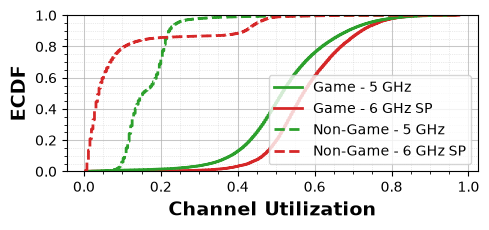

In [38]:
from matplotlib.lines import Line2D

# 1. Filter the dataset
# Assuming you still want to filter for 'ND-guest', remove that line if you want all SSIDs
ecdf_df = df_sigcap_wifi[
    (df_sigcap_wifi['ssid'].str.contains('ND-guest', na=False)) &
    # (df_sigcap_wifi['connected']) &
    (
        (df_sigcap_wifi['freq_label'].isin([5, '5'])) | 
        ((df_sigcap_wifi['freq_label'].isin([6, '6'])) & (df_sigcap_wifi['6ghz_ap_type'].str.upper() == 'SP'))
    )
].copy()

# Create a clean label column for the frequencies to use in the legend
def get_ap_category(row):
    if str(row['freq_label']) == '5':
        return '5 GHz'
    return '6 GHz SP'

ecdf_df['ap_category'] = ecdf_df.apply(get_ap_category, axis=1)

# Drop any rows where ch_util might be NaN so it doesn't break the ECDF
ecdf_df = ecdf_df.dropna(subset=['ch_util'])

# 2. Plot the ECDF
plt.figure(figsize=(5, 2.4))

color_palette = {'5 GHz': 'C2', '6 GHz SP': 'C3'}

# Plot 'Game' data with Solid lines
sns.ecdfplot(
    data=ecdf_df[ecdf_df['game_label'] == 'Game'],
    x='ch_util',
    hue='ap_category',
    palette=color_palette,
    linestyle='-', # Solid
    linewidth=2,
    legend=False   # We will create a custom legend to prevent duplicates
)

# Plot 'Non-Game' data with Dashed lines
sns.ecdfplot(
    data=ecdf_df[ecdf_df['game_label'] == 'Non-Game'],
    x='ch_util',
    hue='ap_category',
    palette=color_palette,
    linestyle='--', # Dashed
    linewidth=2,
    legend=False
)

# plt.title('ECDF of Channel Utilization (5 GHz vs 6 GHz SP)')
plt.xlabel('Channel Utilization', weight='bold', fontsize=14)
plt.ylabel('ECDF', weight='bold', fontsize=14)

# 3. Create a custom Legend
legend_elements = [
    Line2D([0], [0], color='C2', lw=2, linestyle='-', label='Game - 5 GHz'),
    Line2D([0], [0], color='C3', lw=2, linestyle='-', label='Game - 6 GHz SP'),
    Line2D([0], [0], color='C2', lw=2, linestyle='--', label='Non-Game - 5 GHz'),
    Line2D([0], [0], color='C3', lw=2, linestyle='--', label='Non-Game - 6 GHz SP')
]
plt.legend(handles=legend_elements, loc='lower right')

# 4. Add Grid lines for readability
ax = plt.gca()
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.grid(which='major', linestyle='-', linewidth=0.75, alpha=0.7)
ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ecdf_chutil_5ghz_6ghz_sp.pdf", bbox_inches='tight')
plt.show()


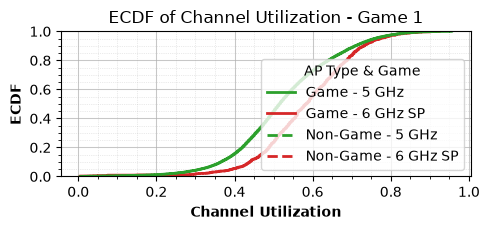

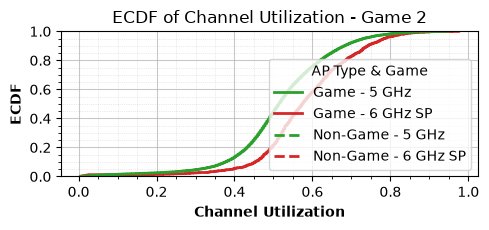

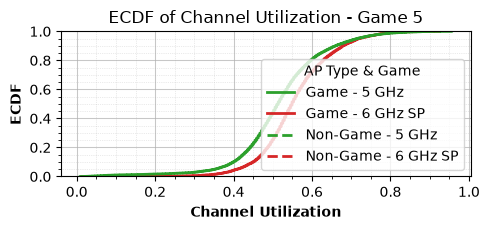

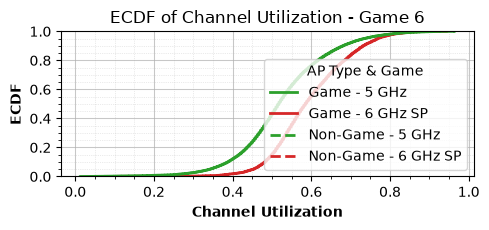

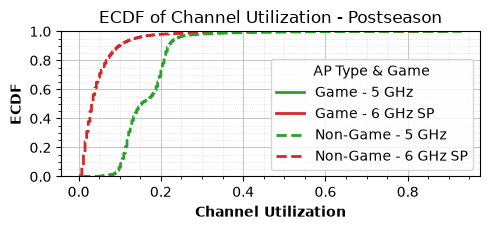

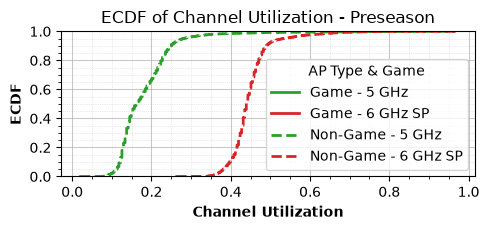

In [39]:

from matplotlib.lines import Line2D

# 1. Filter the dataset
# Assuming you still want to filter for 'ND-guest', remove that line if you want all SSIDs
ecdf_df = df_sigcap_wifi[
    (df_sigcap_wifi['ssid'].str.contains('ND-guest', na=False)) &
    (
        (df_sigcap_wifi['freq_label'].isin([5, '5'])) | 
        ((df_sigcap_wifi['freq_label'].isin([6, '6'])) & (df_sigcap_wifi['6ghz_ap_type'].str.upper() == 'SP'))
    )
].copy()

# Create a clean label column for the frequencies to use in the legend
def get_ap_category(row):
    if str(row['freq_label']) == '5':
        return '5 GHz'
    return '6 GHz SP'

ecdf_df['ap_category'] = ecdf_df.apply(get_ap_category, axis=1)

# Drop any rows where ch_util might be NaN so it doesn't break the ECDF
ecdf_df = ecdf_df.dropna(subset=['ch_util'])

# =========================================================================
# Loop over each unique game_n_label
# =========================================================================
unique_days = ecdf_df['game_n_label'].dropna().unique()
color_palette = {'5 GHz': 'C2', '6 GHz SP': 'C3'}

for day in sorted(unique_days):
    # Filter data for just this specific day
    day_df = ecdf_df[ecdf_df['game_n_label'] == day]
    
    # Skip if there's no data
    if day_df.empty:
        continue

    plt.figure(figsize=(5, 2.4))

    # Plot 'Game' data with Solid lines
    game_data = day_df[day_df['game_label'] == 'Game']
    if not game_data.empty:
        sns.ecdfplot(
            data=game_data,
            x='ch_util', hue='ap_category', palette=color_palette,
            linestyle='-', linewidth=2, legend=False
        )

    # Plot 'Non-Game' data with Dashed lines
    non_game_data = day_df[day_df['game_label'] == 'Non-Game']
    if not non_game_data.empty:
        sns.ecdfplot(
            data=non_game_data,
            x='ch_util', hue='ap_category', palette=color_palette,
            linestyle='--', linewidth=2, legend=False
        )

    plt.title(f'ECDF of Channel Utilization - {day}')
    plt.xlabel('Channel Utilization', weight='bold')
    plt.ylabel('ECDF', weight='bold')

    # Create Custom Legend
    legend_elements = [
        Line2D([0], [0], color='C2', lw=2, linestyle='-', label='Game - 5 GHz'),
        Line2D([0], [0], color='C3', lw=2, linestyle='-', label='Game - 6 GHz SP'),
        Line2D([0], [0], color='C2', lw=2, linestyle='--', label='Non-Game - 5 GHz'),
        Line2D([0], [0], color='C3', lw=2, linestyle='--', label='Non-Game - 6 GHz SP')
    ]
    plt.legend(handles=legend_elements, title='AP Type & Game', loc='lower right')

    # Add Grid lines
    ax = plt.gca()
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.grid(which='major', linestyle='-', linewidth=0.75, alpha=0.7)
    ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

    plt.tight_layout()
    
    # Save the file with the specific day in the filename
    safe_day_str = str(day).replace(' ', '_').replace('/', '-')
    filename = f"ecdf_chutil_5ghz_6ghz_sp_{safe_day_str}.pdf"
    plt.savefig(OUTPUT_DIR / filename)
    
    plt.show()


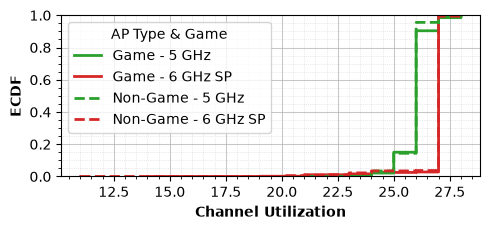

In [40]:
from matplotlib.lines import Line2D

# 1. Filter the dataset
# Assuming you still want to filter for 'ND-guest', remove that line if you want all SSIDs
ecdf_df = df_sigcap_wifi[
    (df_sigcap_wifi['ssid'].str.contains('ND-guest', na=False)) &
    (
        (df_sigcap_wifi['freq_label'].isin([5, '5'])) | 
        ((df_sigcap_wifi['freq_label'].isin([6, '6'])) & (df_sigcap_wifi['6ghz_ap_type'].str.upper() == 'SP'))
    )
].copy()

# Create a clean label column for the frequencies to use in the legend
def get_ap_category(row):
    if str(row['freq_label']) == '5':
        return '5 GHz'
    return '6 GHz SP'

ecdf_df['ap_category'] = ecdf_df.apply(get_ap_category, axis=1)

# Drop any rows where tx_power_dbm might be NaN so it doesn't break the ECDF
ecdf_df = ecdf_df.dropna(subset=['tx_power_dbm'])

# 2. Plot the ECDF
plt.figure(figsize=(5, 2.4))

color_palette = {'5 GHz': 'C2', '6 GHz SP': 'C3'}

# Plot 'Game' data with Solid lines
sns.ecdfplot(
    data=ecdf_df[ecdf_df['game_label'] == 'Game'],
    x='tx_power_dbm',
    hue='ap_category',
    palette=color_palette,
    linestyle='-', # Solid
    linewidth=2,
    legend=False   # We will create a custom legend to prevent duplicates
)

# Plot 'Non-Game' data with Dashed lines
sns.ecdfplot(
    data=ecdf_df[ecdf_df['game_label'] == 'Non-Game'],
    x='tx_power_dbm',
    hue='ap_category',
    palette=color_palette,
    linestyle='--', # Dashed
    linewidth=2,
    legend=False
)

# plt.title('ECDF of Channel Utilization (5 GHz vs 6 GHz SP)')
plt.xlabel('Channel Utilization', weight='bold')
plt.ylabel('ECDF', weight='bold')

# 3. Create a custom Legend
legend_elements = [
    Line2D([0], [0], color='C2', lw=2, linestyle='-', label='Game - 5 GHz'),
    Line2D([0], [0], color='C3', lw=2, linestyle='-', label='Game - 6 GHz SP'),
    Line2D([0], [0], color='C2', lw=2, linestyle='--', label='Non-Game - 5 GHz'),
    Line2D([0], [0], color='C3', lw=2, linestyle='--', label='Non-Game - 6 GHz SP')
]
plt.legend(handles=legend_elements, title='AP Type & Game', loc='upper left')

# 4. Add Grid lines for readability
ax = plt.gca()
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.grid(which='major', linestyle='-', linewidth=0.75, alpha=0.7)
ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ecdf_txpower_5ghz_6ghz_sp.pdf", bbox_inches='tight')
plt.show()


ap_category,5 GHz,6 GHz LPI,6 GHz SP
game_label,,,
Game,16.267943,0.147221,83.584836
Non-Game,13.408610,0.000000,86.591390


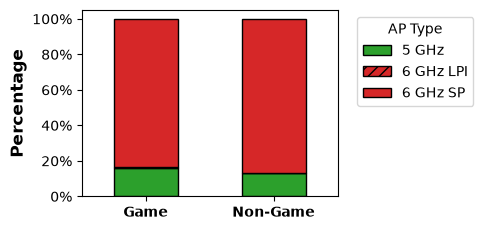

In [41]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# 1. Filter for connected == True (and Freq 5/6)
ratio_df = df_sigcap_wifi[
    (df_sigcap_wifi['connected'] == True) &
    (df_sigcap_wifi['freq_label'].isin(['5', '6', 5, 6]))
    # Add this back if you still want to strictly filter for ND-guest:
    # & (df_sigcap_wifi['ssid'].str.contains('ND-guest', na=False))
].copy()

# Remove 'unknown' 6ghz_ap_type when freq_label is 6
ratio_df = ratio_df[
    ~((ratio_df['freq_label'].isin(['6', 6])) & (ratio_df['6ghz_ap_type'] == 'unknown'))
]

# 2. Assign AP Categories
def get_ap_category(row):
    if str(row['freq_label']) == '5':
        return '5 GHz'
    elif str(row['freq_label']) == '6':
        ap_type = str(row['6ghz_ap_type']).upper()
        if ap_type == 'LPI':
            return '6 GHz LPI'
        elif ap_type == 'SP':
            return '6 GHz SP'
    return 'Unknown'

ratio_df['ap_category'] = ratio_df.apply(get_ap_category, axis=1)
ratio_df = ratio_df[ratio_df['ap_category'] != 'Unknown'] # drop any unknown categories

# 3. Count connections and calculate ratio (0-100%)
# Count by game_label and ap_category
counts = ratio_df.groupby(['game_label', 'ap_category']).size().reset_index(name='count')

# Calculate total connections per game_label, then divide for percentage
total_per_game = counts.groupby('game_label')['count'].transform('sum')
counts['percentage'] = (counts['count'] / total_per_game) * 100

# 4. Pivot dataframe for the stacked bar plot
pivot_df = counts.pivot(index='game_label', columns='ap_category', values='percentage').fillna(0)

# Ensure column order
ordered_cols = ['5 GHz', '6 GHz LPI', '6 GHz SP']
existing_cols = [c for c in ordered_cols if c in pivot_df.columns]
pivot_df = pivot_df[existing_cols]

# 5. Define colors and hatches
color_map = {'5 GHz': 'C2', '6 GHz LPI': 'C3', '6 GHz SP': 'C3'} # Green and Red
colors = [color_map[c] for c in existing_cols]

hatch_map = {'5 GHz': '', '6 GHz LPI': '///', '6 GHz SP': ''}
hatches = [hatch_map[c] for c in existing_cols]

display(pivot_df)

# 6. Create the stacked bar plot
ax = pivot_df.plot(
    kind='bar', 
    stacked=True, 
    figsize=(5, 2.4), 
    color=colors,
    edgecolor='black'
)

# 7. Apply hatches
bars_per_category = len(pivot_df)
for i, bar in enumerate(ax.patches):
    col_idx = i // bars_per_category
    bar.set_hatch(hatches[col_idx])

# 8. Add custom legend
handles = [
    mpatches.Patch(facecolor=color_map[c], hatch=hatch_map[c], edgecolor='black', label=c)
    for c in existing_cols
]

# plt.title('Connection Ratio by Freq Type (Connected)')
plt.xlabel('')
plt.ylabel('Percentage', weight='bold', fontsize=12)

# Format y-axis to show % signs
ax.yaxis.set_major_formatter(mtick.PercentFormatter(100))

plt.legend(handles=handles, title='AP Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "stacked_bar_wifi_conn_ratio.pdf", bbox_inches='tight')
plt.show()


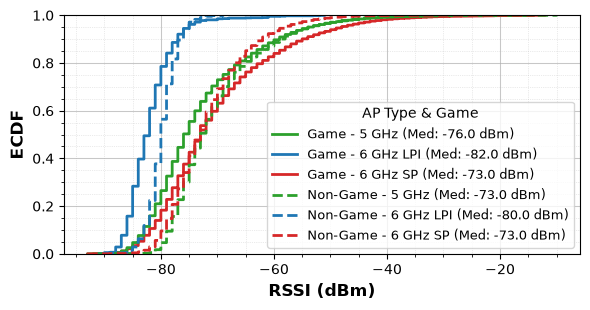

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator

# 1. Filter the dataset
# Includes 5 GHz and 6 GHz (both SP and LPI)
ecdf_df = df_sigcap_wifi[
    (df_sigcap_wifi['ssid'].str.contains('ND-guest', na=False)) &
    # (df_sigcap_wifi['connected']) &
    (
        (df_sigcap_wifi['freq_label'].isin([5, '5'])) | 
        ((df_sigcap_wifi['freq_label'].isin([6, '6'])) & (df_sigcap_wifi['6ghz_ap_type'].str.upper().isin(['SP', 'LPI'])))
    )
].copy()

# Create a clean label column for the frequencies to use in the legend
def get_ap_category(row):
    if str(row['freq_label']) == '5':
        return '5 GHz'
    elif str(row['freq_label']) == '6':
        ap_type = str(row['6ghz_ap_type']).upper()
        if ap_type == 'LPI':
            return '6 GHz LPI'
        elif ap_type == 'SP':
            return '6 GHz SP'
    return 'Unknown'

ecdf_df['ap_category'] = ecdf_df.apply(get_ap_category, axis=1)

# Drop any rows where rssi_dbm might be NaN so it doesn't break the ECDF
ecdf_df = ecdf_df.dropna(subset=['rssi_dbm'])

# Calculate median RSSI values for each category to show in the legend
med_game_5 = ecdf_df[(ecdf_df['game_label'] == 'Game') & (ecdf_df['ap_category'] == '5 GHz')]['rssi_dbm'].median()
med_game_lpi = ecdf_df[(ecdf_df['game_label'] == 'Game') & (ecdf_df['ap_category'] == '6 GHz LPI')]['rssi_dbm'].median()
med_game_sp = ecdf_df[(ecdf_df['game_label'] == 'Game') & (ecdf_df['ap_category'] == '6 GHz SP')]['rssi_dbm'].median()

med_nongame_5 = ecdf_df[(ecdf_df['game_label'] == 'Non-Game') & (ecdf_df['ap_category'] == '5 GHz')]['rssi_dbm'].median()
med_nongame_lpi = ecdf_df[(ecdf_df['game_label'] == 'Non-Game') & (ecdf_df['ap_category'] == '6 GHz LPI')]['rssi_dbm'].median()
med_nongame_sp = ecdf_df[(ecdf_df['game_label'] == 'Non-Game') & (ecdf_df['ap_category'] == '6 GHz SP')]['rssi_dbm'].median()

# 2. Plot the ECDF
plt.figure(figsize=(6, 3.2))

# Color palette: Green (C2) for 5 GHz, Blue (C0) for 6 GHz LPI, Red (C3) for 6 GHz SP
color_palette = {'5 GHz': 'C2', '6 GHz LPI': 'C0', '6 GHz SP': 'C3'}

# Plot 'Game' data with Solid lines
game_df = ecdf_df[ecdf_df['game_label'] == 'Game']
if not game_df.empty:
    sns.ecdfplot(
        data=game_df,
        x='rssi_dbm',
        hue='ap_category',
        palette=color_palette,
        linestyle='-', # Solid
        linewidth=2,
        legend=False   # We will create a custom legend to prevent duplicates
    )

# Plot 'Non-Game' data with Dashed lines
non_game_df = ecdf_df[ecdf_df['game_label'] == 'Non-Game']
if not non_game_df.empty:
    sns.ecdfplot(
        data=non_game_df,
        x='rssi_dbm',
        hue='ap_category',
        palette=color_palette,
        linestyle='--', # Dashed
        linewidth=2,
        legend=False
    )

plt.xlabel('RSSI (dBm)', weight='bold', fontsize=12)
plt.ylabel('ECDF', weight='bold', fontsize=12)

# Helper formatting function for medians
def fmt_med(label, val):
    return f"{label} (Med: {val:.1f} dBm)" if not np.isnan(val) else label

# 3. Create a custom Legend
legend_elements = [
    Line2D([0], [0], color='C2', lw=2, linestyle='-', label=fmt_med('Game - 5 GHz', med_game_5)),
    Line2D([0], [0], color='C0', lw=2, linestyle='-', label=fmt_med('Game - 6 GHz LPI', med_game_lpi)),
    Line2D([0], [0], color='C3', lw=2, linestyle='-', label=fmt_med('Game - 6 GHz SP', med_game_sp)),
    Line2D([0], [0], color='C2', lw=2, linestyle='--', label=fmt_med('Non-Game - 5 GHz', med_nongame_5)),
    Line2D([0], [0], color='C0', lw=2, linestyle='--', label=fmt_med('Non-Game - 6 GHz LPI', med_nongame_lpi)),
    Line2D([0], [0], color='C3', lw=2, linestyle='--', label=fmt_med('Non-Game - 6 GHz SP', med_nongame_sp))
]
plt.legend(handles=legend_elements, title='AP Type & Game', loc='lower right', fontsize=9)

# 4. Add Grid lines for readability
ax = plt.gca()
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.grid(which='major', linestyle='-', linewidth=0.75, alpha=0.7)
ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()


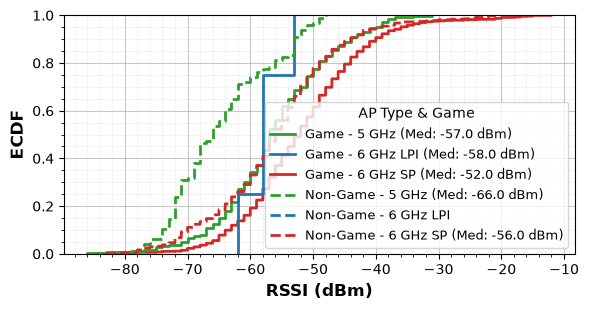

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator

# 1. Filter the dataset
# Includes 5 GHz and 6 GHz (both SP and LPI)
ecdf_df = df_sigcap_wifi[
    (df_sigcap_wifi['ssid'].str.contains('ND-guest', na=False)) &
    (df_sigcap_wifi['connected']) &
    (
        (df_sigcap_wifi['freq_label'].isin([5, '5'])) | 
        ((df_sigcap_wifi['freq_label'].isin([6, '6'])) & (df_sigcap_wifi['6ghz_ap_type'].str.upper().isin(['SP', 'LPI'])))
    )
].copy()

# Create a clean label column for the frequencies to use in the legend
def get_ap_category(row):
    if str(row['freq_label']) == '5':
        return '5 GHz'
    elif str(row['freq_label']) == '6':
        ap_type = str(row['6ghz_ap_type']).upper()
        if ap_type == 'LPI':
            return '6 GHz LPI'
        elif ap_type == 'SP':
            return '6 GHz SP'
    return 'Unknown'

ecdf_df['ap_category'] = ecdf_df.apply(get_ap_category, axis=1)

# Drop any rows where rssi_dbm might be NaN so it doesn't break the ECDF
ecdf_df = ecdf_df.dropna(subset=['rssi_dbm'])

# Calculate median RSSI values for each category to show in the legend
med_game_5 = ecdf_df[(ecdf_df['game_label'] == 'Game') & (ecdf_df['ap_category'] == '5 GHz')]['rssi_dbm'].median()
med_game_lpi = ecdf_df[(ecdf_df['game_label'] == 'Game') & (ecdf_df['ap_category'] == '6 GHz LPI')]['rssi_dbm'].median()
med_game_sp = ecdf_df[(ecdf_df['game_label'] == 'Game') & (ecdf_df['ap_category'] == '6 GHz SP')]['rssi_dbm'].median()

med_nongame_5 = ecdf_df[(ecdf_df['game_label'] == 'Non-Game') & (ecdf_df['ap_category'] == '5 GHz')]['rssi_dbm'].median()
med_nongame_lpi = ecdf_df[(ecdf_df['game_label'] == 'Non-Game') & (ecdf_df['ap_category'] == '6 GHz LPI')]['rssi_dbm'].median()
med_nongame_sp = ecdf_df[(ecdf_df['game_label'] == 'Non-Game') & (ecdf_df['ap_category'] == '6 GHz SP')]['rssi_dbm'].median()

# 2. Plot the ECDF
plt.figure(figsize=(6, 3.2))

# Color palette: Green (C2) for 5 GHz, Blue (C0) for 6 GHz LPI, Red (C3) for 6 GHz SP
color_palette = {'5 GHz': 'C2', '6 GHz LPI': 'C0', '6 GHz SP': 'C3'}

# Plot 'Game' data with Solid lines
game_df = ecdf_df[ecdf_df['game_label'] == 'Game']
if not game_df.empty:
    sns.ecdfplot(
        data=game_df,
        x='rssi_dbm',
        hue='ap_category',
        palette=color_palette,
        linestyle='-', # Solid
        linewidth=2,
        legend=False   # We will create a custom legend to prevent duplicates
    )

# Plot 'Non-Game' data with Dashed lines
non_game_df = ecdf_df[ecdf_df['game_label'] == 'Non-Game']
if not non_game_df.empty:
    sns.ecdfplot(
        data=non_game_df,
        x='rssi_dbm',
        hue='ap_category',
        palette=color_palette,
        linestyle='--', # Dashed
        linewidth=2,
        legend=False
    )

plt.xlabel('RSSI (dBm)', weight='bold', fontsize=12)
plt.ylabel('ECDF', weight='bold', fontsize=12)

# Helper formatting function for medians
def fmt_med(label, val):
    return f"{label} (Med: {val:.1f} dBm)" if not np.isnan(val) else label

# 3. Create a custom Legend
legend_elements = [
    Line2D([0], [0], color='C2', lw=2, linestyle='-', label=fmt_med('Game - 5 GHz', med_game_5)),
    Line2D([0], [0], color='C0', lw=2, linestyle='-', label=fmt_med('Game - 6 GHz LPI', med_game_lpi)),
    Line2D([0], [0], color='C3', lw=2, linestyle='-', label=fmt_med('Game - 6 GHz SP', med_game_sp)),
    Line2D([0], [0], color='C2', lw=2, linestyle='--', label=fmt_med('Non-Game - 5 GHz', med_nongame_5)),
    Line2D([0], [0], color='C0', lw=2, linestyle='--', label=fmt_med('Non-Game - 6 GHz LPI', med_nongame_lpi)),
    Line2D([0], [0], color='C3', lw=2, linestyle='--', label=fmt_med('Non-Game - 6 GHz SP', med_nongame_sp))
]
plt.legend(handles=legend_elements, title='AP Type & Game', loc='lower right', fontsize=9)

# 4. Add Grid lines for readability
ax = plt.gca()
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.grid(which='major', linestyle='-', linewidth=0.75, alpha=0.7)
ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()


In [44]:
import numpy as np
import pandas as pd

# 1. Filter the dataset for ND-guest and relevant frequencies/AP types
ratio_df = df_sigcap_wifi[
    (df_sigcap_wifi['ssid'].str.contains('ND-guest', na=False)) &
    (
        (df_sigcap_wifi['freq_label'].isin([5, '5'])) | 
        ((df_sigcap_wifi['freq_label'].isin([6, '6'])) & (df_sigcap_wifi['6ghz_ap_type'].str.upper().isin(['SP', 'LPI'])))
    )
].copy()

# 2. Assign AP Categories
def get_ap_category(row):
    if str(row['freq_label']) == '5':
        return '5 GHz'
    elif str(row['freq_label']) == '6':
        ap_type = str(row['6ghz_ap_type']).upper()
        if ap_type == 'LPI':
            return '6 GHz LPI'
        elif ap_type == 'SP':
            return '6 GHz SP'
    return 'Unknown'

ratio_df['ap_category'] = ratio_df.apply(get_ap_category, axis=1)

# Drop rows with missing RSSI values
ratio_df = ratio_df.dropna(subset=['rssi_dbm'])

# 3. Create pivot table for Connected-only devices (connected == True)
connected_df = ratio_df[ratio_df['connected'] == True]
pivot_connected = connected_df.pivot_table(
    index='game_label',
    columns='ap_category',
    values='rssi_dbm',
    aggfunc='median'
)
pivot_connected.index = pd.MultiIndex.from_product([pivot_connected.index, ['Connected']])

# 4. Create pivot table for All devices (Connected + Neighbors)
pivot_all = ratio_df.pivot_table(
    index='game_label',
    columns='ap_category',
    values='rssi_dbm',
    aggfunc='median'
)
pivot_all.index = pd.MultiIndex.from_product([pivot_all.index, ['All (Connected + Neighbors)']])

# 5. Combine and structure the tables
combined_pivot = pd.concat([pivot_connected, pivot_all])

# Reindex to ensure proper order of rows (Game first, then Non-Game) and columns
row_order = pd.MultiIndex.from_product([['Game', 'Non-Game'], ['Connected', 'All (Connected + Neighbors)']])
combined_pivot = combined_pivot.reindex(row_order)

ordered_cols = ['5 GHz', '6 GHz LPI', '6 GHz SP']
existing_cols = [col for col in ordered_cols if col in combined_pivot.columns]
combined_pivot = combined_pivot[existing_cols]

# Clean up index/column headers for LaTeX representation
combined_pivot.index.names = ['Scenario', 'Connection State']
combined_pivot.columns.name = 'AP Category'

# 6. Generate LaTeX-formatted table (removed multicol_format and multirow parameters)
latex_table = combined_pivot.to_latex(
    float_format="{:.1f} dBm".format,
    caption="Median RSSI Values for 5 GHz, 6 GHz LPI, and 6 GHz SP by Scenario and Connection State (ND-guest SSID)",
    label="tab:median_rssi_dimensions",
    column_format="ll" + "c" * len(existing_cols)
)

print(latex_table)


\begin{table}
\caption{Median RSSI Values for 5 GHz, 6 GHz LPI, and 6 GHz SP by Scenario and Connection State (ND-guest SSID)}
\label{tab:median_rssi_dimensions}
\begin{tabular}{llccc}
\toprule
 & AP Category & 5 GHz & 6 GHz LPI & 6 GHz SP \\
Scenario & Connection State &  &  &  \\
\midrule
\multirow[t]{2}{*}{Game} & Connected & -57.0 dBm & -58.0 dBm & -52.0 dBm \\
 & All (Connected + Neighbors) & -76.0 dBm & -82.0 dBm & -73.0 dBm \\
\cline{1-5}
\multirow[t]{2}{*}{Non-Game} & Connected & -66.0 dBm & NaN & -56.0 dBm \\
 & All (Connected + Neighbors) & -73.0 dBm & -80.0 dBm & -73.0 dBm \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



In [45]:
import numpy as np
import pandas as pd

# 1. Filter the dataset for ND-guest and relevant frequencies/AP types
ratio_df = df_sigcap_wifi[
    (df_sigcap_wifi['ssid'].str.contains('ND-guest', na=False)) &
    (df_sigcap_wifi['connected']) &
    (
        (df_sigcap_wifi['freq_label'].isin([5, '5'])) | 
        ((df_sigcap_wifi['freq_label'].isin([6, '6'])) & (df_sigcap_wifi['6ghz_ap_type'].str.upper().isin(['SP', 'LPI'])))
    )
].copy()

# 2. Assign AP Categories
def get_ap_category(row):
    if str(row['freq_label']) == '5':
        return '5 GHz'
    elif str(row['freq_label']) == '6':
        ap_type = str(row['6ghz_ap_type']).upper()
        if ap_type == 'LPI':
            return '6 GHz LPI'
        elif ap_type == 'SP':
            return '6 GHz SP'
    return 'Unknown'

ratio_df['ap_category'] = ratio_df.apply(get_ap_category, axis=1)

# Drop rows with missing RSSI values
ratio_df = ratio_df.dropna(subset=['rssi_dbm'])

# 3. Create pivot table calculating the median RSSI
pivot_table = ratio_df.pivot_table(
    index='game_label',
    columns='ap_category',
    values='rssi_dbm',
    aggfunc='median'
)

# Reorder columns logically
ordered_cols = ['5 GHz', '6 GHz LPI', '6 GHz SP']
existing_cols = [col for col in ordered_cols if col in pivot_table.columns]
pivot_table = pivot_table[existing_cols]

# Clean up index/column headers for LaTeX representation
pivot_table.index.name = 'Scenario'
pivot_table.columns.name = 'AP Category'

# 4. Generate LaTeX-formatted table
latex_table = pivot_table.to_latex(
    float_format="{:.1f} dBm".format,
    caption="Comparison of median RSSI for connected 5 GHz, 6 GHz LPI, and 6 GHz SP.",
    label="tab:median_rssi",
    column_format="l" + "c" * len(existing_cols)
)

print(latex_table)


\begin{table}
\caption{Comparison of median RSSI for connected 5 GHz, 6 GHz LPI, and 6 GHz SP.}
\label{tab:median_rssi}
\begin{tabular}{lccc}
\toprule
AP Category & 5 GHz & 6 GHz LPI & 6 GHz SP \\
Scenario &  &  &  \\
\midrule
Game & -57.0 dBm & -58.0 dBm & -52.0 dBm \\
Non-Game & -66.0 dBm & NaN & -56.0 dBm \\
\bottomrule
\end{tabular}
\end{table}



In [46]:
import pandas as pd

df_sigcap_wifi_correction = pd.read_csv(
    DATA_DIR / 'game5_sigcap_csv/20251108_sigcap_bowl_wifi.csv', parse_dates=['timestamp']
).assign(game_label='Game', game_n_label='Game 5')
df_sigcap_wifi_correction = df_sigcap_wifi_correction[df_sigcap_wifi_correction['timestamp'] < '2025-11-08 21:38:42-0500']

df_sigcap_wifi = pd.concat([
    pd.read_csv(DATA_DIR / 'game1_sigcap_csv/20250913_sigcap_sta_wifi_bow.csv', parse_dates=['timestamp']).assign(game_label='Game', game_n_label='Game 1'),
    pd.read_csv(DATA_DIR / 'game2_sigcap_csv/20250920_sigcap_sta_wifi_bow.csv', parse_dates=['timestamp']).assign(game_label='Game', game_n_label='Game 2'),
    pd.read_csv(DATA_DIR / 'game5_sigcap_csv/20251108_sigcap_bowl_wifi.csv', parse_dates=['timestamp']).assign(game_label='Game', game_n_label='Game 5'),
    pd.read_csv(DATA_DIR / 'game6_sigcap_csv/20251122_sigcap_bowl_wifi.csv', parse_dates=['timestamp']).assign(game_label='Game', game_n_label='Game 6'),
    pd.read_csv(DATA_DIR / 'preseason_sigcap_csv/20250828_SigCap_wifi_bow_s22.csv', parse_dates=['timestamp']).assign(game_label='Non-Game', game_n_label='Preseason'),
    pd.read_csv(DATA_DIR / 'postseason_sigcap_csv/2026_02_S26_1030_E26_1247Z-0500_outdoor_Verizon_7c36e7df_sta_mr_vzw_bow.debug_wifi.csv', parse_dates=['timestamp']).assign(game_label='Non-Game', game_n_label='Postseason'),
    pd.read_csv(DATA_DIR / 'postseason_sigcap_csv/2026_02_S26_1117_E26_1247Z-0500_outdoor_T-Mobile_a0654bd3_sta_at_tmo_bow.debug_wifi.csv', parse_dates=['timestamp']).assign(game_label='Non-Game', game_n_label='Postseason'),
    pd.read_csv(DATA_DIR / 'postseason_sigcap_csv/2026_02_S26_1124_E26_1246Z-0500_outdoor_AT&T_fbd516f0_sta_mr_att_bow.debug_wifi.csv', parse_dates=['timestamp']).assign(game_label='Non-Game', game_n_label='Postseason'),
    df_sigcap_wifi_correction
])

df_sigcap_wifi['freq_label'] = df_sigcap_wifi['primary_freq_mhz'].apply(
    lambda x: ('2.4' if x < 3000
                else '6' if x >= 5925
                else '5'))
df_sigcap_wifi['unii_label'] = df_sigcap_wifi['primary_freq_mhz'].apply(
    lambda x: ('2.4' if x < 3000
                else 'U-NII-1' if x > 5150 and x <= 5250
                else 'U-NII-2A' if x > 5250 and x <= 5350
                else 'U-NII-2B' if x > 5350 and x <= 5470
                else 'U-NII-2C' if x > 5470 and x <= 5725
                else 'U-NII-3' if x > 5725 and x <= 5850
                else 'U-NII-4' if x > 5850 and x <= 5925
                else 'U-NII-5' if x > 5925 and x <= 6425
                else 'U-NII-6' if x > 6425 and x <= 6525
                else 'U-NII-7' if x > 6525 and x <= 6875
                else 'U-NII-8' if x > 6875 and x <= 7125
                else 'unknown'))

df_sigcap_wifi.shape[0]


1889707

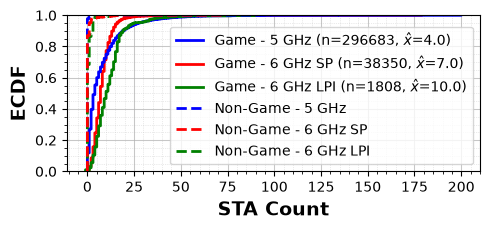

In [47]:
from matplotlib.lines import Line2D

# 1. Filter the dataset
# Assuming you still want to filter for 'ND-guest', remove that line if you want all SSIDs
ecdf_df = df_sigcap_wifi[
    (df_sigcap_wifi['ssid'].str.contains('ND-guest', na=False)) &
    # (df_sigcap_wifi['connected']) &
    (
        (df_sigcap_wifi['freq_label'].isin([5, '5'])) | 
        (df_sigcap_wifi['freq_label'].isin([6, '6']))
        # ((df_sigcap_wifi['freq_label'].isin([6, '6'])) & (df_sigcap_wifi['6ghz_ap_type'].str.upper() == 'LPI'))
    )
].copy()

# Create a clean label column for the frequencies to use in the legend
def get_ap_category(row):
    if str(row['freq_label']) == '5':
        return '5 GHz'
    elif row['6ghz_ap_type'].upper() == 'SP':
        return '6 GHz SP' 
    return '6 GHz LPI'

ecdf_df['ap_category'] = ecdf_df.apply(get_ap_category, axis=1)

# Drop any rows where sta_count might be NaN so it doesn't break the ECDF
ecdf_df = ecdf_df.dropna(subset=['sta_count'])

# 2. Plot the ECDF
plt.figure(figsize=(5, 2.4))

color_palette = {'5 GHz': 'blue', '6 GHz SP': 'red', '6 GHz LPI': 'green'}

# Plot 'Game' data with Solid lines
sns.ecdfplot(
    data=ecdf_df[ecdf_df['game_label'] == 'Game'],
    x='sta_count',
    hue='ap_category',
    palette=color_palette,
    linestyle='-', # Solid
    linewidth=2,
    legend=False   # We will create a custom legend to prevent duplicates
)
med_5 = ecdf_df[
    (ecdf_df['game_label'] == 'Game') &
    (ecdf_df['ap_category'] == '5 GHz')
]['sta_count'].median()
med_6_sp = ecdf_df[
    (ecdf_df['game_label'] == 'Game') &
    (ecdf_df['ap_category'] == '6 GHz SP')
]['sta_count'].median()
med_6_lpi = ecdf_df[
    (ecdf_df['game_label'] == 'Game') &
    (ecdf_df['ap_category'] == '6 GHz LPI')
]['sta_count'].median()
count_5 = ecdf_df[
    (ecdf_df['game_label'] == 'Game') &
    (ecdf_df['ap_category'] == '5 GHz')
]['sta_count'].count()
count_6_sp = ecdf_df[
    (ecdf_df['game_label'] == 'Game') &
    (ecdf_df['ap_category'] == '6 GHz SP')
]['sta_count'].count()
count_6_lpi = ecdf_df[
    (ecdf_df['game_label'] == 'Game') &
    (ecdf_df['ap_category'] == '6 GHz LPI')
]['sta_count'].count()

# Plot 'Non-Game' data with Dashed lines
sns.ecdfplot(
    data=ecdf_df[ecdf_df['game_label'] == 'Non-Game'],
    x='sta_count',
    hue='ap_category',
    palette=color_palette,
    linestyle='--', # Dashed
    linewidth=2,
    legend=False
)

# plt.title('ECDF of Channel Utilization (5 GHz vs 6 GHz SP)')
plt.xlabel('STA Count', weight='bold', fontsize=14)
plt.ylabel('ECDF', weight='bold', fontsize=14)

# 3. Create a custom Legend
legend_elements = [
    Line2D([0], [0], color='blue', lw=2, linestyle='-', label=fr'Game - 5 GHz (n={count_5}, $\hat{{x}}$={med_5})'),
    Line2D([0], [0], color='red', lw=2, linestyle='-', label=fr'Game - 6 GHz SP (n={count_6_sp}, $\hat{{x}}$={med_6_sp})'),
    Line2D([0], [0], color='green', lw=2, linestyle='-', label=fr'Game - 6 GHz LPI (n={count_6_lpi}, $\hat{{x}}$={med_6_lpi})'),
    Line2D([0], [0], color='blue', lw=2, linestyle='--', label='Non-Game - 5 GHz'),
    Line2D([0], [0], color='red', lw=2, linestyle='--', label='Non-Game - 6 GHz SP'),
    Line2D([0], [0], color='green', lw=2, linestyle='--', label='Non-Game - 6 GHz LPI')
]
plt.legend(handles=legend_elements, loc='lower right')

# 4. Add Grid lines for readability
ax = plt.gca()
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.grid(which='major', linestyle='-', linewidth=0.75, alpha=0.7)
ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ecdf_sta_count_5ghz_6ghz_sp_lpi.png", bbox_inches='tight')
plt.show()


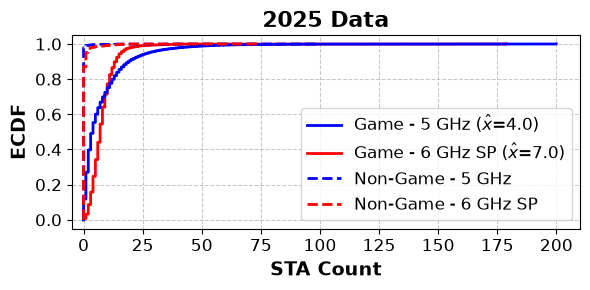

In [48]:
from matplotlib.lines import Line2D

# 1. Filter the dataset
# Assuming you still want to filter for 'ND-guest', remove that line if you want all SSIDs
ecdf_df = df_sigcap_wifi[
    (df_sigcap_wifi['ssid'].str.contains('ND-guest', na=False)) &
    # (df_sigcap_wifi['connected']) &
    (
        (df_sigcap_wifi['freq_label'].isin([5, '5'])) | 
        # (df_sigcap_wifi['freq_label'].isin([6, '6']))
        ((df_sigcap_wifi['freq_label'].isin([6, '6'])) & (df_sigcap_wifi['6ghz_ap_type'].str.upper() == 'SP'))
    )
].copy()

# Create a clean label column for the frequencies to use in the legend
def get_ap_category(row):
    if str(row['freq_label']) == '5':
        return '5 GHz'
    elif row['6ghz_ap_type'].upper() == 'SP':
        return '6 GHz SP' 
    return '6 GHz LPI'

ecdf_df['ap_category'] = ecdf_df.apply(get_ap_category, axis=1)

# Drop any rows where sta_count might be NaN so it doesn't break the ECDF
ecdf_df = ecdf_df.dropna(subset=['sta_count'])

# 2. Plot the ECDF
plt.figure(figsize=(6, 3))

color_palette = {'5 GHz': 'blue', '6 GHz SP': 'red', '6 GHz LPI': 'green'}

# Plot 'Game' data with Solid lines
sns.ecdfplot(
    data=ecdf_df[ecdf_df['game_label'] == 'Game'],
    x='sta_count',
    hue='ap_category',
    palette=color_palette,
    linestyle='-', # Solid
    linewidth=2,
    legend=False   # We will create a custom legend to prevent duplicates
)
med_5 = ecdf_df[
    (ecdf_df['game_label'] == 'Game') &
    (ecdf_df['ap_category'] == '5 GHz')
]['sta_count'].median()
med_6_sp = ecdf_df[
    (ecdf_df['game_label'] == 'Game') &
    (ecdf_df['ap_category'] == '6 GHz SP')
]['sta_count'].median()
med_6_lpi = ecdf_df[
    (ecdf_df['game_label'] == 'Game') &
    (ecdf_df['ap_category'] == '6 GHz LPI')
]['sta_count'].median()

# Plot 'Non-Game' data with Dashed lines
sns.ecdfplot(
    data=ecdf_df[ecdf_df['game_label'] == 'Non-Game'],
    x='sta_count',
    hue='ap_category',
    palette=color_palette,
    linestyle='--', # Dashed
    linewidth=2,
    legend=False
)

plt.title("2025 Data",fontsize=16, fontweight='bold')
plt.xlabel('STA Count', weight='bold', fontsize=14)
plt.ylabel('ECDF', weight='bold', fontsize=14)

# 3. Create a custom Legend
legend_elements = [
    Line2D([0], [0], color='blue', lw=2, linestyle='-', label=fr'Game - 5 GHz ($\hat{{x}}$={med_5})'),
    Line2D([0], [0], color='red', lw=2, linestyle='-', label=fr'Game - 6 GHz SP ($\hat{{x}}$={med_6_sp})'),
    # Line2D([0], [0], color='green', lw=2, linestyle='-', label=fr'Game - 6 GHz LPI ($\hat{{x}}$={med_6_lpi})'),
    Line2D([0], [0], color='blue', lw=2, linestyle='--', label='Non-Game - 5 GHz'),
    Line2D([0], [0], color='red', lw=2, linestyle='--', label='Non-Game - 6 GHz SP'),
    # Line2D([0], [0], color='green', lw=2, linestyle='--', label='Non-Game - 6 GHz LPI')
]
plt.legend(fontsize=12, handles=legend_elements, loc='lower right')

# 4. Add Grid lines for readability
ax = plt.gca()
# ax.yaxis.set_minor_locator(AutoMinorLocator())
# ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.grid(which='major', linestyle='--', linewidth=0.75, alpha=0.7)
# ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

#plt.ylim(0, 100)
plt.ylim(-0.05, 1.05)
plt.xlim(-5, 210)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ecdf_sta_count_2025.png", bbox_inches='tight')
plt.show()


In [49]:
ecdf_df[
    (ecdf_df['game_label'] == 'Game') &
    (ecdf_df['ap_category'] == '6 GHz SP')
]['sta_count'].max()

np.float64(179.0)